**DSC 148 — Introduction to Data Mining · Course Project**

# Swing or Take? Predicting MLB Batter Decisions

---

### Research Question

*Can pitch location, pitch type, velocity, pitch count, and matchup context predict whether an MLB batter **swings** or **takes** a pitch?*

### Hypothesis

Batters are more likely to swing at pitches **near or inside the strike-zone**, especially with **two strikes**. Pitch type, pitch speed, pitch count, and batter/pitcher handedness should also carry predictive signal for the batter's decision to swing or take.


### Why is this important?
One of the most influential and prominent on-field actions is the decision for a batter to either take a swing at the ball or take the ball. Several game-changing occurrences can arise from a swing decision, including but not limited to strikes, base-hits, home-runs, or changes to the ball-strike numeric count. With enough insight into the swing decision, teams can decipher discipline at the plate and help pilot development in hitting and getting on base strategies by creating a comprehensive understanding of the batter versus pitcher dynamic. Focusing on the behaviors of players when they swing the bat, this study aims to fill research gaps regarding the decision-making of batters based on the type of pitch and situational occurrences.

This research stands to promote a large impact for the sports world and help demonstrate the real-life applications of data-mining by helping to predict swing decisions. Variables like pitch placement, pitch count, pitch velocity, and who the batter is up against can all dramatically change a swing decisions. The results of this swing-deciding study have potential to help sporting talents, especially mentors and evaluators at the forefront of hitting, take informed decisions in the sporting world to help gain an edge. This study serves to exhibit how the data of this scale can help elicit a form of prediction in a large scope.

## 0. Setup


The dataset was collected using the Python package called **pybaseball**, which provides access to MLB statcast data. Pitch-level data from the 2025 MLB season was retrieved using the statcast() function for games played between March 18, 2025 and September 28, 2025. After downloading the full dataset, there were over 700K+ rows and it was too much for a computer to handle. Therefore, I decided to do a random sample of 75,000 pitches using a fixed random seed to crate a more manageable dataset for analysis. The resulting sample was then exported as a CSV file for preprocessing, exploratory data analysis, and model development. 

Now, let's load in the dataset!

In [59]:
import pandas as pd

df = pd.read_csv("mlb_statcast_2025_75k.csv")

df

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2025-09-23,83.2,-2.30,5.60,"Vásquez, Randy",663368,681190,NaN,ball,...,4.0,2.80,-0.61,0.61,26.9,NaN,NaN,NaN,NaN,NaN
1,FC,2025-07-19,92.9,-1.88,5.77,"Agnos, Zach",686797,688642,NaN,ball,...,2.0,2.06,0.07,-0.07,35.7,NaN,NaN,NaN,NaN,NaN
2,FF,2025-09-14,92.5,-1.65,5.09,"Nola, Aaron",695600,605400,strikeout,swinging_strike,...,2.0,1.60,0.92,-0.92,18.0,-1.878938,27.627179,21.150673,41.768807,19.940736
3,FF,2025-04-17,94.1,-1.20,5.61,"Bachar, Lake",672695,669199,NaN,called_strike,...,1.0,0.87,1.01,-1.01,39.4,NaN,NaN,NaN,NaN,NaN
4,ST,2025-09-20,83.8,-1.74,5.35,"Abel, Mick",672356,690953,NaN,ball,...,1.0,3.60,-0.89,-0.89,26.1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,SL,2025-07-27,85.4,-0.82,5.76,"Gilbert, Logan",650859,669302,NaN,called_strike,...,1.0,3.19,0.09,-0.09,41.0,NaN,NaN,NaN,NaN,NaN
74996,FF,2025-07-05,95.3,-1.64,6.33,"Fermin, José",543807,820862,NaN,called_strike,...,1.0,1.20,0.60,0.60,46.3,NaN,NaN,NaN,NaN,NaN
74997,SL,2025-03-19,81.3,2.16,6.13,"Steele, Justin",669257,657006,walk,ball,...,8.0,3.63,-1.12,1.12,NaN,NaN,NaN,NaN,NaN,NaN
74998,FF,2025-05-29,95.4,-2.25,5.83,"Gusto, Ryan",666139,687473,NaN,ball,...,2.0,1.07,0.47,-0.47,44.3,NaN,NaN,NaN,NaN,NaN


Let's import all the things we will need (potentially).

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, log_loss,
                             average_precision_score, roc_curve, confusion_matrix,
                             classification_report)

np.random.seed(42)

PAL = {"swing": "#d1495b", "take": "#1b7ed6", "accent": "#2a9d8f", "warn": "#e9c46a"}

# 1. Dataset

To recap once again, we will use a 2025 MLB Statcast dataset containing 75,000 randomly sampled pitches. Statcast is Major League Baseball's advanced tracking system that records detailed information about every pitch that is thrown during a game. This includes pitch location, velocity, movement, pitch type, game situation, and player information. These data provide a comprehensive view of the factors that may influence a batter's decision to swing or take a pitch.

Each row represents a single pitch. The dataset spans the 2025 regular season and contains 118 raw columns that describe pitch characteristics, batter and pitcher attributes, game context, and pitch outcomes.

We'll start off by loading in the dataset and doing simple summary statistics on it.

In [61]:
mlb = pd.read_csv("mlb_statcast_2025_75k.csv")


print("Shape of dataset:", mlb.shape)
print("Unique batters:", mlb["batter"].nunique(), "| Unique pitchers:", mlb["pitcher"].nunique())
mlb.head(3)

Shape of dataset: (75000, 118)
Unique batters: 1029 | Unique pitchers: 1046


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2025-09-23,83.2,-2.30,5.60,"Vásquez, Randy",663368,681190,NaN,ball,...,4.0,2.80,-0.61,0.61,26.9,NaN,NaN,NaN,NaN,NaN
1,FC,2025-07-19,92.9,-1.88,5.77,"Agnos, Zach",686797,688642,NaN,ball,...,2.0,2.06,0.07,-0.07,35.7,NaN,NaN,NaN,NaN,NaN
2,FF,2025-09-14,92.5,-1.65,5.09,"Nola, Aaron",695600,605400,strikeout,swinging_strike,...,2.0,1.60,0.92,-0.92,18.0,-1.878938,27.627179,21.150673,41.768807,19.940736


### 1.1 Defining the target: *swing* vs *take*

Statcast does not store a literal "swing" flag, but the description field records the **result** of every pitcher, from which the batter's intent is explicit enough to tell. Therefore, we will make a binary label that will be mapped to descriptions:

- **SWING(1):**  Outcomes that indicate the batter offered at the pitch, including swinging_strike, swinging_strike_blocked, foul, foul_tip, hit_into_play, and bunt-attempt variants.

- **Take(0):** Outcomes where the batter did not swing, including ball, called_strike, blocked_ball, and hit_by_pitch.

- **Excluded Outcomes:** automatic_ball, automatic_strike, and pitchout were removed because they do not represent a true swing-or-take decision by the batter. Excluding these events ensures that the target variable reflects only genuine hitter decisions.

This data-cleaning step was taken to ensure that the target variable accurately reflects a batter's actual decision to swing or take a pitch. Events that do not involve a genuine choice by the batter were removed rather than assigned to either class, allowing the model to focus only on real swing decisions.

In [62]:
# Examine the distribution of pitch outcomes
print("Pitch outcome distribution:")
print(mlb["description"].value_counts(dropna=False).to_string())

# Define outcome groups
swing_events = {
    "foul", "hit_into_play", "swinging_strike", "foul_tip",
    "swinging_strike_blocked", "foul_bunt", "missed_bunt", "bunt_foul_tip"
}

take_events = {
    "ball", "called_strike", "blocked_ball", "hit_by_pitch"
}

excluded_events = {
    "automatic_ball", "automatic_strike", "pitchout"
}

# Keep only pitches that represent a true swing-or-take decision
original_rows = len(mlb)
mlb = mlb[mlb["description"].isin(swing_events | take_events)].copy()

# Create binary target variable
# 1 = Swing, 0 = Take
mlb["swing"] = mlb["description"].isin(swing_events).astype(int)

# Summary
print(f"\nRows retained: {len(mlb):,}")
print(f"Rows excluded: {original_rows - len(mlb):,}")
print(f"Overall swing rate: {mlb['swing'].mean():.3f}")
print("\nTarget distribution:")
print(mlb["swing"].value_counts().rename({0: "Take", 1: "Swing"}))

Pitch outcome distribution:
description
ball                       25143
foul                       13313
hit_into_play              13193
called_strike              12151
swinging_strike             7858
blocked_ball                1567
foul_tip                     759
swinging_strike_blocked      419
automatic_ball               241
hit_by_pitch                 190
foul_bunt                    125
missed_bunt                   19
automatic_strike              17
pitchout                       3
bunt_foul_tip                  2

Rows retained: 74,739
Rows excluded: 261
Overall swing rate: 0.478

Target distribution:
swing
Take     39051
Swing    35688
Name: count, dtype: int64


As we can see from the summary statistics, the overall swing rate is about 0.478. This means that the dataset is nearly balanced between swings and takes. Because of this, accuracy is a reasonable baseline metric because a trivial majority-class model would not perform very well. However, accuracy alone is not enough to evaluate performance.

We will also report F1 score, ROC-AUC, PR-AUC, and log loss. The goal is not just classification, but a probabilistic model that can estimate swing likelihood in different pitch and game situations.

### 1.2 Missingness & core-feature cleaning

This cell assesses data completeness at the feature level and graphs the results in a bar chart. It divides data features into core columns, which are strictly required and must be present, and tracking columns, which are somewhat required. Missing values are expressed as percentages to allow better feature level comparisons. The data set gets cleaned through removal of rows with missing core data features, and missing tracking values get imputed with the median value. It prints the number of rows removed and the dimensions of the cleaned dataset.

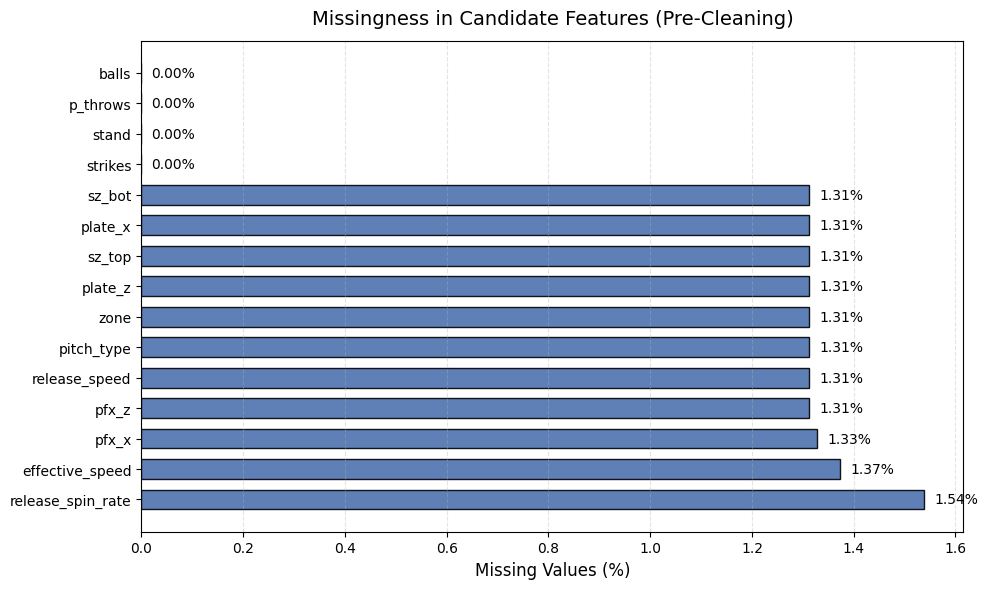

Dropped 981 rows missing core tracking features.
Final dataset size: 73,758


In [63]:
# Define features
core_cols = [
    "plate_x", "plate_z", "sz_top", "sz_bot", "release_speed",
    "pitch_type", "zone", "balls", "strikes", "stand", "p_throws"
]

tracking_cols = [
    "pfx_x", "pfx_z", "release_spin_rate", "effective_speed"
]

all_cols = core_cols + tracking_cols

# Compute missingness (%)
miss = (
    mlb[all_cols]
    .isna()
    .mean()
    .sort_values(ascending=True) * 100
)

# KEEP ALL FEATURES (don’t drop zeros)
# miss = miss[miss > 0]   <-- removed intentionally

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    miss.index,
    miss.values,
    color="#4C72B0",
    edgecolor="black",
    height=0.65,
    alpha=0.9
)

ax.set_title("Missingness in Candidate Features (Pre-Cleaning)", fontsize=14, pad=12)
ax.set_xlabel("Missing Values (%)", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)

ax.invert_yaxis()

# value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Cleaning step
before = len(mlb)

mlb = mlb.dropna(subset=core_cols).copy()

for c in tracking_cols:
    mlb[c] = mlb[c].fillna(mlb[c].median())

print(f"Dropped {before - len(mlb):,} rows missing core tracking features.")
print(f"Final dataset size: {len(mlb):,}")

### 1.3 Feature engineering

The raw Statcast tracking variables are already informative, but they are not in the most useful form for prediction. I created engineered features that better represent the geometry of the swing decision and the game context.

Let's start with the strike-zone geometry:

**I model the strike-zonee as a batter-specific rectangle defined by `sz_top` and `sz_bot`, with a fixed horizontal width. Pitch locations are normalized so that values near ±1 represent the edge of the zone. I also construct a single summary measure of location:**
- `norm_x = plate_x / 0.83` represents horizontal location relative to zone width
- `norm_z = (plate_z − sz_mid) / sz_halfheight` represents vertical location relative to zone height
- `radial_dist = sqrt(norm_x^2 + norm_z^2)` measures distance from the zone center, where 0 is the center, 1 is near the edge, and values above 1 are farther away from the center
- `in_zone` is a binary indicator for whether the pitch is inside the strike-zonee. This closely matches Statcast's zone field and serves as a useful sanity check


**Count context:**

We encode the game situation using features such as `two_strike`, `three_ball`, `count_diff = balls − strikes`, and flags indicating whether the hitter or pitcher is ahead in the count. These capture the pressure and risk level of the pitch.

**Pitch type:**

Pitch types are grouped into higher-level categories (`Fastball`, `Breaking`, `Offspeed`, `Other`) to reduce complexity and better reflect how hitters think about pitch types.

**Matchup and handedness:**

We include `platoon`, which indicates same-handed versus opposite-handed matchups, along with raw handedness indicators `stand_R` and `throw_R`.

**Sequence features:**

To capture within-at-bat dynamics, we sort pitches in chronological order and add features based on the previous pitch, such as `prev_swing`, `prev_in_zone`, and `is_first_pitch`. These features only use information available before the current pitch, so they do not introduce any leakage that is directly associated with the outcome.

In [64]:
HALF_PLATE = 0.83  # half plate width in feet

# strike-zone geometry
mlb["sz_mid"] = (mlb["sz_top"] + mlb["sz_bot"]) / 2
mlb["sz_halfh"] = (mlb["sz_top"] - mlb["sz_bot"]) / 2

mlb["norm_x"] = mlb["plate_x"] / HALF_PLATE
mlb["norm_z"] = (mlb["plate_z"] - mlb["sz_mid"]) / mlb["sz_halfh"]

mlb["radial_dist"] = np.sqrt(mlb["norm_x"]**2 + mlb["norm_z"]**2)

mlb["in_zone"] = (
    (mlb["norm_x"].abs() <= 1) &
    (mlb["norm_z"].abs() <= 1)
).astype(int)

mlb["abs_px"] = mlb["plate_x"].abs()

# count context
mlb["two_strike"] = (mlb["strikes"] == 2).astype(int)
mlb["three_ball"] = (mlb["balls"] == 3).astype(int)

mlb["count_diff"] = mlb["balls"] - mlb["strikes"]
mlb["hitter_count"] = (mlb["count_diff"] >= 1).astype(int)
mlb["pitcher_count"] = (mlb["count_diff"] <= -1).astype(int)

# pitch grouping
pitch_group_map = {
    "FF": "Fastball", "SI": "Fastball", "FC": "Fastball", "FA": "Fastball",
    "SL": "Breaking", "ST": "Breaking", "CU": "Breaking", "KC": "Breaking",
    "SV": "Breaking", "CS": "Breaking", "SC": "Breaking", "KN": "Breaking",
    "CH": "Offspeed", "FS": "Offspeed", "FO": "Offspeed", "EP": "Offspeed",
    "PO": "Other", "UN": "Other"
}

mlb["pitch_group"] = mlb["pitch_type"].map(pitch_group_map).fillna("Other")

# matchup features
mlb["platoon"] = (mlb["stand"] == mlb["p_throws"]).astype(int)
mlb["stand_R"] = (mlb["stand"] == "R").astype(int)
mlb["throw_R"] = (mlb["p_throws"] == "R").astype(int)

# sequence features
mlb = mlb.sort_values(["game_pk", "at_bat_number", "pitch_number"]).reset_index(drop=True)

grouped = mlb.groupby(["game_pk", "at_bat_number"])

mlb["prev_swing"] = grouped["swing"].shift(1)
mlb["prev_in_zone"] = grouped["in_zone"].shift(1)

mlb["is_first_pitch"] = mlb["prev_swing"].isna().astype(int)

mlb["prev_swing"] = mlb["prev_swing"].fillna(0)
mlb["prev_in_zone"] = mlb["prev_in_zone"].fillna(0)

mlb[
    ["plate_x", "plate_z", "norm_x", "norm_z",
     "radial_dist", "in_zone", "pitch_group",
     "count_diff", "swing"]
].head()

,plate_x,plate_z,norm_x,norm_z,radial_dist,in_zone,pitch_group,count_diff,swing
0,-0.708806,3.571956,-0.853983,1.160518,1.440864,0,Fastball,1,0
1,-1.126677,3.325346,-1.357443,0.909958,1.634220,0,Fastball,0,0
2,-1.087555,1.020467,-1.310308,-1.658954,2.114009,0,Breaking,1,1
3,-0.131298,2.016273,-0.158190,-0.651045,0.669988,1,Fastball,2,1
4,0.372495,2.534495,0.448789,0.125137,0.465908,1,Offspeed,-1,1


### 1.4 Exploratory Data Analysis

We now explore the dataset to (a) test our hypothesis and (b) guide model design decisions, with each result interpreted in terms of its implications for modeling.

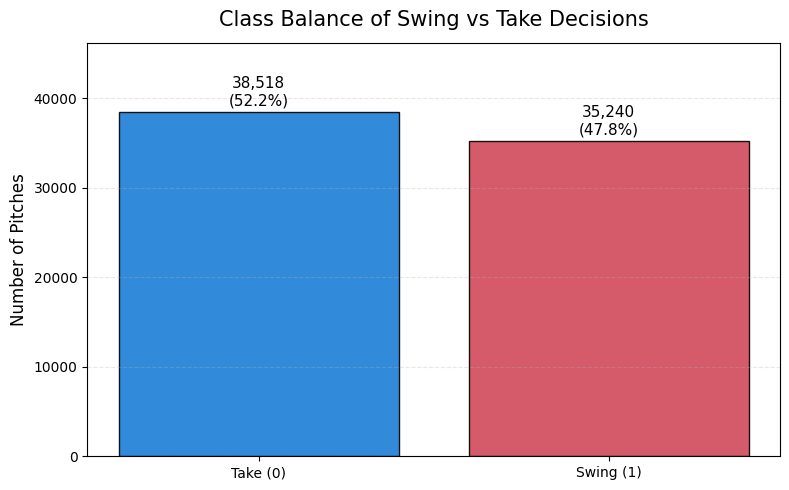

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

vc = mlb["swing"].value_counts().sort_index()

labels = ["Take (0)", "Swing (1)"]
colors = [PAL["take"], PAL["swing"]]

bars = ax.bar(labels, vc.values, color=colors, edgecolor="black", alpha=0.9)

# Value labels
for i, v in enumerate(vc.values):
    ax.text(
        i,
        v + 0.01 * vc.max(),
        f"{v:,}\n({v/len(mlb):.1%})",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Class Balance of Swing vs Take Decisions", fontsize=15, pad=12)
ax.set_ylabel("Number of Pitches", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_ylim(0, vc.max() * 1.2)

plt.tight_layout()
plt.show()

The dataset is about **48% swings and 52% takes**, so it is nearly balanced. This means a simple model that always predicts the majority class (take) would achieve about 52% accuracy, which serves as a baseline performance level.

#### (b) Testing the Central Hypothesis: Swing probability across the strike-zonee
If pitch location is a key driver of swing decisions, swing rates should be highest near the center of the strike-zone and decrease as pitches move farther away. To test this, we bin plate_x and plate_z into a grid and compute the average swing rate within each bin. We then visualize this as a heatmap, with the strike-zone overlaid to compare observed swing behavior against the official zone boundaries.

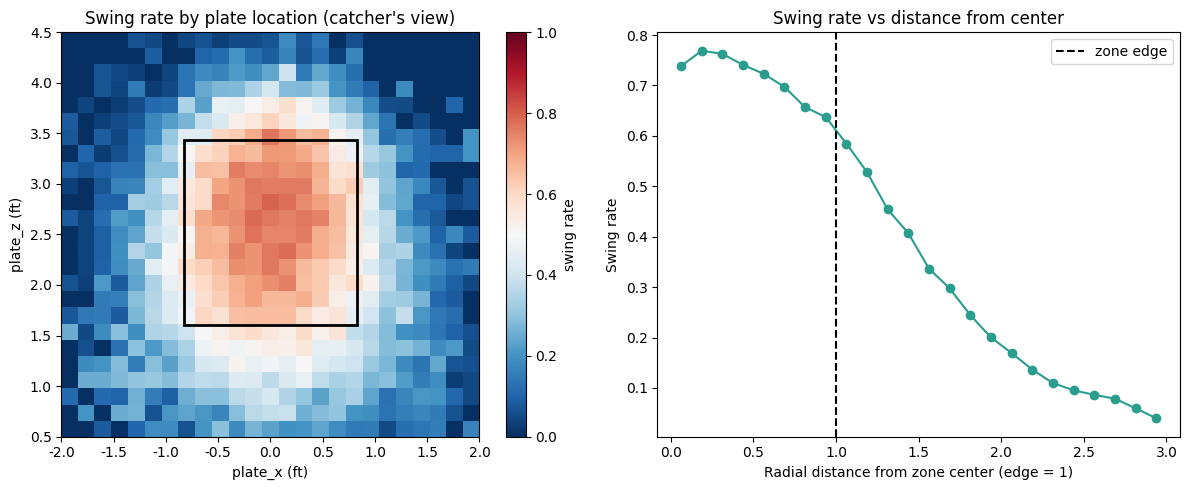

In-zone swing rate: 0.680 | Out-of-zone swing rate: 0.301


In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

# create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# define bin edges
xb = np.linspace(-2, 2, 26)
zb = np.linspace(0.5, 4.5, 26)

# bin pitch locations
mlb["_xbin"] = pd.cut(mlb["plate_x"], xb, include_lowest=True)
mlb["_zbin"] = pd.cut(mlb["plate_z"], zb, include_lowest=True)

# compute swing rate grid
grid = (
    mlb.groupby(["_zbin", "_xbin"], observed=True)["swing"]
    .mean()
    .unstack()
    .fillna(0)
)

# plot heatmap
im = axes[0].imshow(
    grid.values,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    extent=[xb[0], xb[-1], zb[0], zb[-1]],
    vmin=0,
    vmax=1
)

# draw strike zone
sz_b, sz_t = mlb["sz_bot"].mean(), mlb["sz_top"].mean()

axes[0].add_patch(
    Rectangle(
        (-HALF_PLATE, sz_b),
        2 * HALF_PLATE,
        sz_t - sz_b,
        fill=False,
        edgecolor="black",
        lw=2
    )
)

axes[0].set_title("Swing rate by plate location (catcher's view)")
axes[0].set_xlabel("plate_x (ft)")
axes[0].set_ylabel("plate_z (ft)")

fig.colorbar(im, ax=axes[0], label="swing rate")

# radial distance bins
rb = np.linspace(0, 3, 25)

mlb["_rbin"] = pd.cut(mlb["radial_dist"], rb, include_lowest=True)

# compute swing rate by distance
prof = mlb.groupby("_rbin", observed=True)["swing"].mean()

centers = (rb[:-1] + rb[1:]) / 2

# plot distance curve
axes[1].plot(
    centers,
    prof.values,
    "-o",
    color=PAL["accent"]
)

axes[1].axvline(1, ls="--", color="black", label="zone edge")

axes[1].set_xlabel("Radial distance from zone center (edge = 1)")
axes[1].set_ylabel("Swing rate")
axes[1].set_title("Swing rate vs distance from center")
axes[1].legend()

plt.tight_layout()
plt.show()

# cleanup temporary columns
mlb.drop(columns=["_xbin", "_zbin", "_rbin"], inplace=True)

# summary statistic
print(
    "In-zone swing rate: {:.3f} | Out-of-zone swing rate: {:.3f}".format(
        mlb.loc[mlb.in_zone == 1, "swing"].mean(),
        mlb.loc[mlb.in_zone == 0, "swing"].mean()
    )
)

These two graphs present good evidence for the hypothesis. The heatmap shows that most players exhibit the highest swing probability in the middle of the strike zone. The further away the pitches are from the middle, the lower the probability of the players swinging. The probability of a player swinging the further away the pitches are from the middle of the strike zone decreases steadily, until the edge of the strike zone (`radial_dist = 1`), where the behavior goes from aggressive to selective.

The in-zone swing rate is about 0.680, while the out-of-zone swing rate is about 0.301. The right graph also supports this claim by showing that as radial distance increases, swing probability decreases in a consistent and smooth manner.

**Implication:** Pitch location is a strong predictor and is the most important factor in the given data set. The smooth gradient shows that hitters would likely respond to a location on the strike zone bound probabilistically, rather than absolutely. With a decision surface that is nonlinear and radially organized, tree-based ensembles and the like, would likely perform much better than a strictly linear model.

#### (c.) The two-strike effect on swing probability

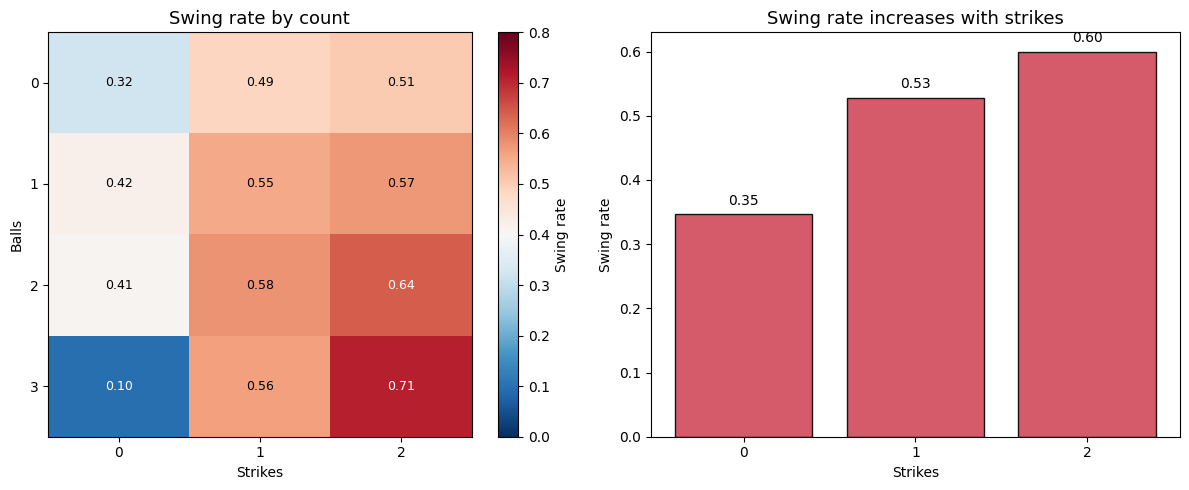

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# swing rate heatmap by count
ct = mlb.groupby(["balls", "strikes"])["swing"].mean().unstack()

im = axes[0].imshow(
    ct.values,
    cmap="RdBu_r",
    vmin=0,
    vmax=0.8,
    aspect="auto"
)

axes[0].set_title("Swing rate by count", fontsize=13)
axes[0].set_xlabel("Strikes")
axes[0].set_ylabel("Balls")

axes[0].set_xticks(range(ct.shape[1]))
axes[0].set_xticklabels(ct.columns)
axes[0].set_yticks(range(ct.shape[0]))
axes[0].set_yticklabels(ct.index)

# annotate heatmap
for (i, j), v in np.ndenumerate(ct.values):
    axes[0].text(
        j,
        i,
        f"{v:.2f}",
        ha="center",
        va="center",
        color="white" if abs(v - 0.4) > 0.22 else "black",
        fontsize=9
    )

fig.colorbar(im, ax=axes[0], label="Swing rate")

# swing rate by strikes
byk = mlb.groupby("strikes")["swing"].mean()

axes[1].bar(
    byk.index.astype(str),
    byk.values,
    color=PAL["swing"],
    edgecolor="black",
    alpha=0.9
)

axes[1].set_title("Swing rate increases with strikes", fontsize=13)
axes[1].set_xlabel("Strikes")
axes[1].set_ylabel("Swing rate")

# annotate bars
for i, v in enumerate(byk.values):
    axes[1].text(
        i,
        v + 0.01,
        f"{v:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

This offers compelling evidence for the hypothesis with additional considerations. The swing rate increases with the number of strikes. Hitters become more aggressive after falling behind in the count. A 3-0 count has a low swing rate of 0.10. A 3-2 count has a swing rate of 0.71. This clearly shows that hitters are making strategic changes rather than randomly varying behavior.

The count likely interacts with the pitch location, and to a degree makes the count less relevant. Context and leverage are critical to hitters when making decisions to swing, as the count plays a role. Pitches that are borderline may be taken in a more hitter-friendly 3-0 count, though are much more likely to be swung at in a more aggressive count that has a hitter closer to the strikeout. This suggests that additive models may lack important interactions, which indicates that tree-based models or boosting may be more appropriate for this.

#### (d) Pitch type, Velocity, and Handedness

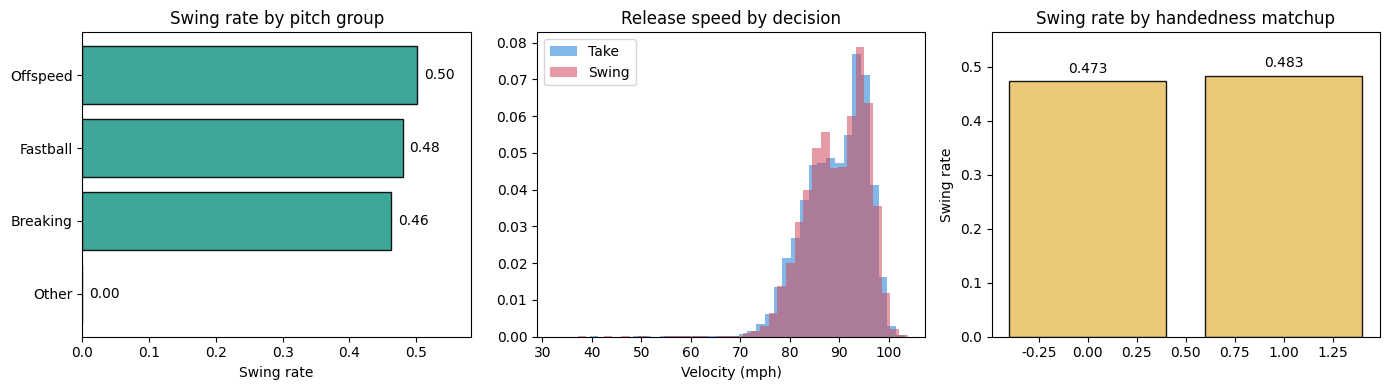

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# swing rate by pitch group
pg = mlb.groupby("pitch_group")["swing"].mean().sort_values()

axes[0].barh(
    pg.index,
    pg.values,
    color=PAL["accent"],
    edgecolor="black",
    alpha=0.9
)

axes[0].set_title("Swing rate by pitch group", fontsize=12)
axes[0].set_xlabel("Swing rate")

# add extra space on the right so labels do not get cut off
axes[0].set_xlim(0, pg.max() + 0.08)

for i, v in enumerate(pg.values):
    axes[0].text(v + 0.01, i, f"{v:.2f}", va="center")

# release speed distributions
for s, c in [(0, PAL["take"]), (1, PAL["swing"])]:
    axes[1].hist(
        mlb.loc[mlb.swing == s, "release_speed"],
        bins=40,
        alpha=0.55,
        density=True,
        color=c,
        label="Swing" if s else "Take"
    )

axes[1].set_title("Release speed by decision", fontsize=12)
axes[1].set_xlabel("Velocity (mph)")
axes[1].legend()

# handedness matchup
plat = mlb.groupby("platoon")["swing"].mean()

axes[2].bar(
    plat.index,
    plat.values,
    color=PAL["warn"],
    edgecolor="black",
    alpha=0.9
)

axes[2].set_title("Swing rate by handedness matchup", fontsize=12)
axes[2].set_ylabel("Swing rate")

# add extra space on top so labels do not get cut off
axes[2].set_ylim(0, plat.max() + 0.08)

for i, v in enumerate(plat.values):
    axes[2].text(i, v + 0.015, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

Pitch characteristics likely do not strongly indicate swing decisions. However, evidence shows that pitch types do not significantly contribute to the formation of a swing decision. Conversely, which pitch type is thrown does not account for the majority of swing decisions. Movements of pitches and deception appear to play more of a role than the type of pitch being thrown. There is also a significant overlap of the release-speed distributions when comparing swings and ttakes, suggesting that velocity alone does not sufficiently differentiate the two decisions. There is only a small difference in swing rates, and in same-handed matchups, there is an increase in swings.

Therefore, groups of variables of interest like pitch characteristics, velocity, and handedness, may likely yield limited value by themselves. Likely, the overall value of these variables may be realized when they are interacting with other variables such as pitch location, count, and the batter’s previous and contextual tendencies. These findings also support the use of an ablation study to determine how significantly isolated groups of variables may likely influence swing/take decisions.

#### (e.) Feature correlations

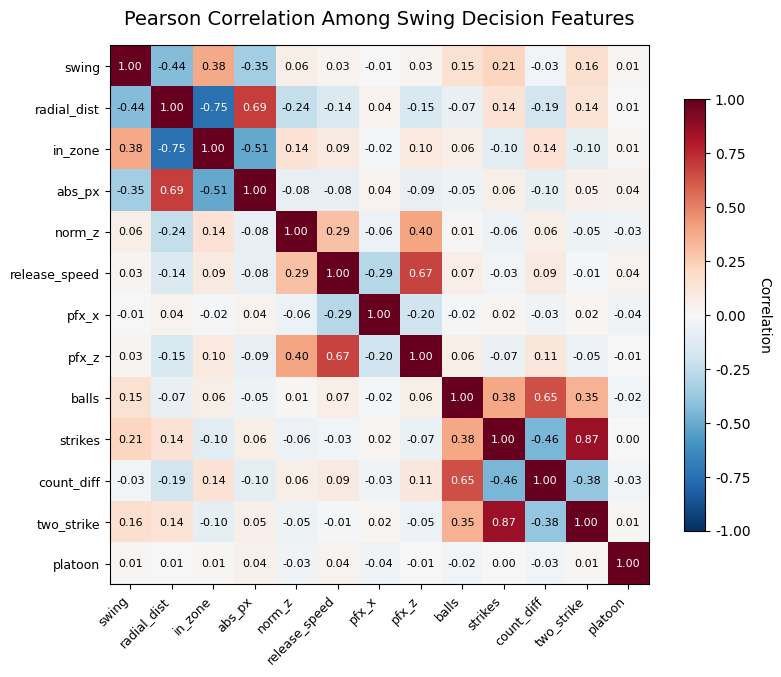

In [69]:
# columns to include in the correlation heatmap
corr_cols = [
    "swing", "radial_dist", "in_zone", "abs_px", "norm_z",
    "release_speed", "pfx_x", "pfx_z",
    "balls", "strikes", "count_diff", "two_strike", "platoon"
]

# keep only columns that actually exist in mlb
corr_cols = [col for col in corr_cols if col in mlb.columns]

# compute Pearson correlation matrix
C = mlb[corr_cols].dropna().corr()

# create figure
fig, ax = plt.subplots(figsize=(9, 7))

# heatmap
im = ax.imshow(
    C.values,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

# axis labels
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# write correlation values inside cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = C.iloc[i, j]
        ax.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(value) > 0.55 else "black"
        )

# title and colorbar
ax.set_title(
    "Pearson Correlation Among Swing Decision Features",
    fontsize=14,
    pad=15
)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Correlation", rotation=270, labelpad=15)

The correlation heatmap shows that location-related features have the strongest relationship with swing decisions. `radial_dist` has the strongest ngative correlation with swing, meaning hitters are less likely to swing at pitches more farther from the center of the strike-zonee. `in_zone` is postively correlatd with swing, which makes sense because hitters are likely to offer (swing) at pitches in or near the strike-zone. Other features, such as release speed, movement, count, and handedness matchup have much weaker individual correlations with swing behavior.

There are also noticeable collinearity that I see among some predictors, especially location variables and count variables. For example, `radial_dist`, `in_zon`, and `abs_px` are naturally related becaus they all describe pitch location. `strikes` and `two_strike` are strongly correlated because the two-strike counts are directly derived from the number of strikes.

This implies that pitch location appears to be the most important single feature group for prdicting swings, while velocity, movement, count, and platoon effects likely add amounts of information. This also suggests that a simple model such as logistic regrssion can be useful, but models that can handle feature interactions may perform better. Naive Bayes could also work, but its conditional-independence assumption is clearly only an approximation because several of these predictors are related to each other.

#### (f) Unsupervised Structure — PCA  and K-Means

Before proceeding with supervised modeling, we try two unsupervised learning techniques to explore the structure of the pitch data.

We start with Principal Component Analysis (PCA) to see which physical pitch features capture the main components of pitch movement, speed, and trajectory. Standardized Physical Pitch Descriptors simplify dimensions. PCA helps us identify if physical pitch features are represented by a small number of components.

The second technique is K-Means clustering, which we apply to normalized plate-location features to picture the neighborhood locations of the strike-zone. After forming these neighborhoods, we analyze the neighborhoods’ swing rates, which provides a window to understand the effect of pitch location on swing vs take decisions.

PCA and K-Means clustering are effective when used in conjunction, as PCA captures the pitch space’s dimensions and K-Means clustering captures swing behavior’s variability in the strike-zone.

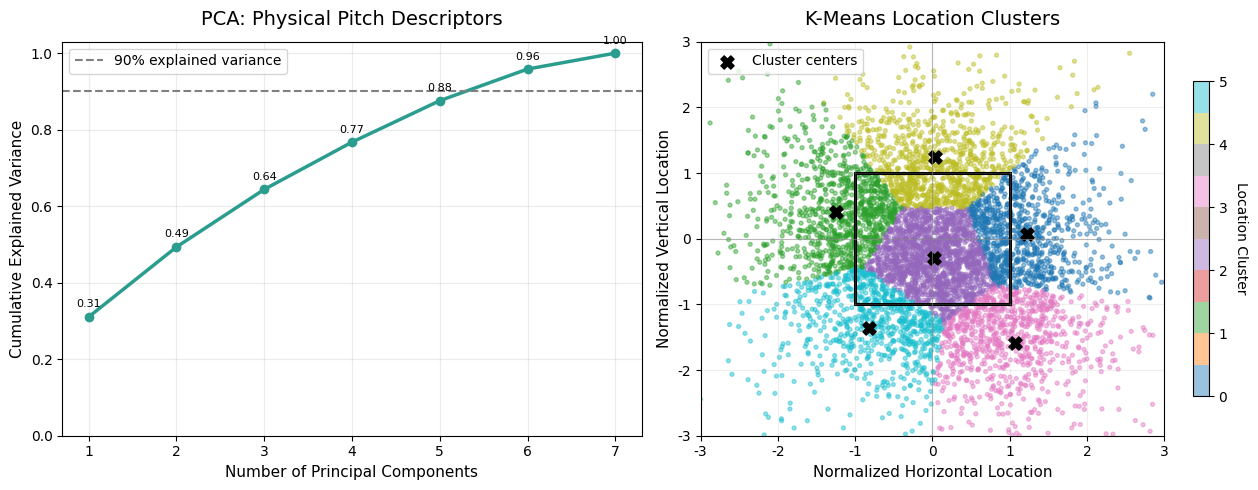

                 n  swing_rate  mean_radius  mean_norm_x  mean_norm_z
loc_cluster                                                          
2            19350       0.706        0.553        0.017       -0.285
4            11736       0.488        1.344        0.031        1.242
0            11018       0.418        1.333        1.230        0.079
1            11409       0.386        1.414       -1.246        0.413
5             9714       0.380        1.684       -0.814       -1.357
3            10531       0.298        2.005        1.070       -1.592


In [70]:
pca_feats = [
    "release_speed",
    "plate_x",
    "plate_z",
    "pfx_x",
    "pfx_z",
    "radial_dist",
    "release_spin_rate"
]

needed_cols = pca_feats + ["norm_x", "norm_z", "swing"]
plot_df = mlb[needed_cols].dropna().copy()

Zp = StandardScaler().fit_transform(plot_df[pca_feats])

pca = PCA()
pca.fit(Zp)

cum_var = np.cumsum(pca.explained_variance_ratio_)
components = np.arange(1, len(pca_feats) + 1)

loc = plot_df[["norm_x", "norm_z"]].values

km = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

plot_df["loc_cluster"] = km.fit_predict(loc)

samp = plot_df.sample(
    min(6000, len(plot_df)),
    random_state=0
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    components,
    cum_var,
    marker="o",
    linewidth=2.5,
    color=PAL["accent"]
)

axes[0].axhline(
    0.90,
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="90% explained variance"
)

axes[0].set_title("PCA: Physical Pitch Descriptors", fontsize=14, pad=12)
axes[0].set_xlabel("Number of Principal Components", fontsize=11)
axes[0].set_ylabel("Cumulative Explained Variance", fontsize=11)
axes[0].set_xticks(components)
axes[0].set_ylim(0, 1.03)
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=True)

for x, y in zip(components, cum_var):
    axes[0].text(
        x,
        y + 0.025,
        f"{y:.2f}",
        ha="center",
        fontsize=8
    )

sc = axes[1].scatter(
    samp["norm_x"],
    samp["norm_z"],
    c=samp["loc_cluster"],
    cmap="tab10",
    s=8,
    alpha=0.45
)

axes[1].add_patch(
    Rectangle(
        (-1, -1),
        2,
        2,
        fill=False,
        edgecolor="black",
        linewidth=2.2
    )
)

axes[1].scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    c="black",
    s=90,
    marker="X",
    label="Cluster centers"
)

axes[1].set_title("K-Means Location Clusters", fontsize=14, pad=12)
axes[1].set_xlabel("Normalized Horizontal Location", fontsize=11)
axes[1].set_ylabel("Normalized Vertical Location", fontsize=11)
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].axhline(0, color="gray", linewidth=0.8, alpha=0.5)
axes[1].axvline(0, color="gray", linewidth=0.8, alpha=0.5)
axes[1].grid(alpha=0.2)
axes[1].legend(frameon=True)

cbar = fig.colorbar(sc, ax=axes[1], shrink=0.8)
cbar.set_label("Location Cluster", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

clu = (
    plot_df
    .groupby("loc_cluster")
    .agg(
        n=("swing", "size"),
        swing_rate=("swing", "mean"),
        mean_radius=("radial_dist", "mean"),
        mean_norm_x=("norm_x", "mean"),
        mean_norm_z=("norm_z", "mean")
    )
    .sort_values("swing_rate", ascending=False)
    .round(3)
)

print(clu)

The left graph (PCA) presents a picture of the structure of physical pitch details. These details are not entirely captured by one or two dimensions. The first principal component captures approximately 31% of the variance. The next 2 capture a cumulative total of approximately 64%. The next 1 captures approximately 13%. The next 2 total about 6% combined. So, a reasonable estimate is that 6 to 8 principal components are needed to explain a cumulative total of more than 90%. Because of this, significant dimensionality reduction is not necessary. Keeping the original features is more useful because they are easier to interpret.

The right graph (K-Means) depicts the variability of decisions to swing by strike zone. When pitches are grouped by normalized plate location, the group in the center of the plate has the highest swing rate of 0.706. This group is also the smallest, with a mean radius of 0.553. In each of the clusters further from the center of the strike zone, the swing rate is lower. The cluster with the largest mean radius has a mean of 2.005, and a swing rate of 0.298. The outer clusters have swing rates between approximately 0.38 and 0.49.

The graphs combined bring forth the idea of the model. Physical pitch details are important, but the K-Means results suggest that pitch location will likely be one of the most important factors in the model that predicts swing/take.

#### (g). Association-Rule Mining

We adopt association-rule mining to characterize swing behaviors using simple terms of baseball “situations.” Each pitch creates a transaction where items are boolean. Examples of boolean items include, whether the pitch was in the strike zone, did the batter have two strikes, was the pitch fast, and did the batter take a swing. These are all options that allow us to make thes association rules with one another.

From these transactions, we are able to generate context → decision rules. Examples include pitch-count combinations that lead to a swing or take, and vice versa. For each rule, we append support, confidence, and lift. Support measures the frequency of the situation, confidence assesses the strength of the correlated decision, and lift determines the likelihood of the decision overall.

Using the rules, instead of just the models, we assess project hypothesis and determine whether specific pitch situations strongly correlate with take or swing decisions. For rules, we are able to determine whether a model accurately predicts take or swing decisions based on the examples we provided.

In [71]:
# make a clean copy with the columns needed for association rules
rule_df = mlb[
    ["in_zone", "strikes", "balls", "pitch_group", "swing"]
].dropna().copy()

# define each boolean item
items = {
    "in_zone": rule_df["in_zone"] == 1,
    "out_zone": rule_df["in_zone"] == 0,
    "two_strike": rule_df["strikes"] == 2,
    "zero_strike": rule_df["strikes"] == 0,
    "three_ball": rule_df["balls"] == 3,
    "fastball": rule_df["pitch_group"] == "Fastball",
    "swing": rule_df["swing"] == 1,
    "take": rule_df["swing"] == 0
}

# function to compute support, confidence, and lift for one rule
def rule(antecedent, consequent):
    A = items[antecedent]
    C = items[consequent]

    # support: percent of all pitches where both antecedent and consequent happen
    support = (A & C).mean()

    # confidence: among pitches with antecedent, percent that also have consequent
    confidence = (A & C).sum() / A.sum() if A.sum() > 0 else np.nan

    # lift: how much more likely the consequent is given the antecedent
    base_rate = C.mean()
    lift = confidence / base_rate if base_rate > 0 else np.nan

    return {
        "rule": f"{antecedent} => {consequent}",
        "support": round(float(support), 3),
        "confidence": round(float(confidence), 3),
        "lift": round(float(lift), 2)
    }

# antecedent conditions to test
antecedents = [
    "in_zone",
    "out_zone",
    "two_strike",
    "zero_strike",
    "three_ball",
    "fastball"
]

# build rule table for both swing and take decisions
rules = pd.DataFrame([
    rule(a, c)
    for a in antecedents
    for c in ["swing", "take"]
])

# sort by lift so the strongest associations appear first
rules = rules.sort_values("lift", ascending=False)

# display the rule table
print(rules.to_string(index=False))

                rule  support  confidence  lift
    in_zone => swing    0.317       0.680  1.42
    out_zone => take    0.373       0.699  1.34
 two_strike => swing    0.180       0.600  1.26
 zero_strike => take    0.259       0.654  1.25
 three_ball => swing    0.048       0.598  1.25
   fastball => swing    0.265       0.480  1.00
    fastball => take    0.287       0.520  1.00
  two_strike => take    0.120       0.400  0.77
  three_ball => take    0.033       0.402  0.77
zero_strike => swing    0.137       0.346  0.72
   out_zone => swing    0.160       0.301  0.63
     in_zone => take    0.150       0.320  0.61


The association rules validate the hypothesis that pitch location and count correspond to certain swing decisions. The strongest positive association rule in the data was found to be in_zone ⇒ swing, exhibiting a confidence of 0.680 and lift of 1.42. This rule suggests that if a pitch is deemed to be in the strike zone, a hitter is predicted to swing about 68% of the time, and this is about 1.42 times the overall swing propensity.

There is also a contrary rule: out_zone ⇒ take. This rule also demonstrates a high confidence of 0.699 and a lift of 1.34, meaning that pitches that are taken by the hitters are more likely to be outside of the strike zone. The aggressiveness of the hitter also depends on the count. With two strikes, hitters are more likely to swing, while the count of zero strikes tends to make hitters more likely to take.

There was also a strong agreement of the rules in the expected direction of the game. Overall, good zone pitches generally Increase swing rates. Conversely, good take pitches that are out of the zone, increase take rates, and generally increase aggressiveness with two-strike counts. The gray area poses the most challenge to the model. With a more advanced model, we can identify more combinations of pitch location, count, pitch type, and movement.

#### (h) Robustness: Does the Main Finding Hold Across Subsamples?

We also verify that the main pattern holds across different parts of the data, in order to make sure that the main conclusion is not simply an artifact of one train-test split. From this finding, btters are more likely to swing at pitches that are inside the strike zone than at pitches that are outside of the strike zone. If this relation is real and robust, it should be reproducible in natural subsamples of the data.

To further test this, the data is broken down by batter handedness, pitcher handedness, and by inning. An even better extension would be to have even more seasons with pybaseball, but this robustness check within a dataset still shows how stable is the result.

If the in-zone vs. out-of-zone swing gap is similar, then it makes our conclusion stronger because it relates more to it. This further shows that location effect is not causd by one group of players or one part of the sason, but it is a generl pattern in a batter's decision making. 

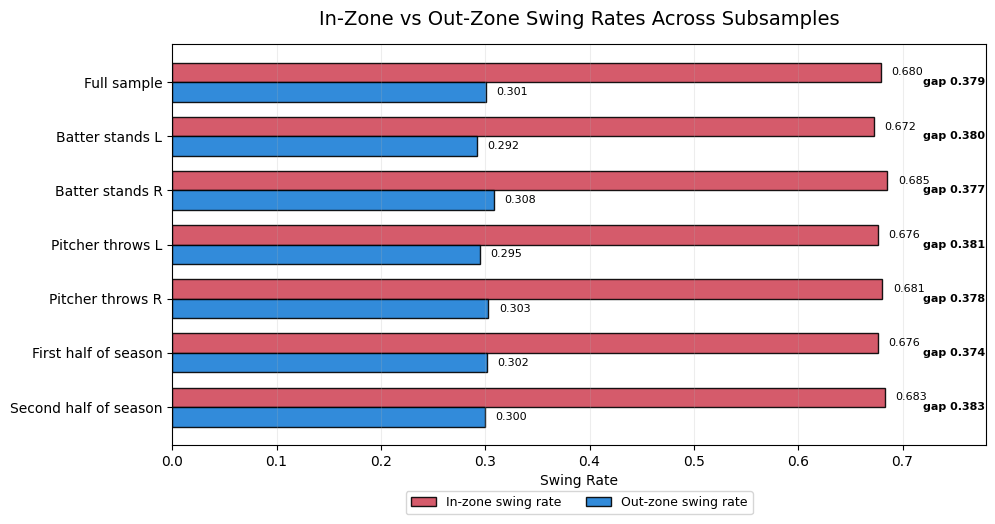

In [72]:
# plot in-zone and out-zone swing rates by segment
fig, ax = plt.subplots(figsize=(10.5, 5.2))

y_positions = np.arange(len(robustness_df))
bar_height = 0.36

ax.barh(
    y_positions - bar_height / 2,
    robustness_df["in_zone_swing_rate"],
    height=bar_height,
    color=PAL["swing"],
    edgecolor="black",
    alpha=0.9,
    label="In-zone swing rate"
)

ax.barh(
    y_positions + bar_height / 2,
    robustness_df["out_zone_swing_rate"],
    height=bar_height,
    color=PAL["take"],
    edgecolor="black",
    alpha=0.9,
    label="Out-zone swing rate"
)

ax.set_title(
    "In-Zone vs Out-Zone Swing Rates Across Subsamples",
    fontsize=14,
    pad=14
)

ax.set_xlabel("Swing Rate")
ax.set_ylabel("")
ax.set_yticks(y_positions)
ax.set_yticklabels(robustness_df["segment"], fontsize=10)
ax.set_xlim(0, 0.78)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.22)

# add swing-rate labels at the end of each bar
for i, row in robustness_df.iterrows():
    in_rate = row["in_zone_swing_rate"]
    out_rate = row["out_zone_swing_rate"]
    gap = row["gap"]

    ax.text(
        in_rate + 0.01,
        i - bar_height / 2,
        f"{in_rate:.3f}",
        va="center",
        fontsize=8
    )

    ax.text(
        out_rate + 0.01,
        i + bar_height / 2,
        f"{out_rate:.3f}",
        va="center",
        fontsize=8
    )

    ax.text(
        0.72,
        i,
        f"gap {gap:.3f}",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

# move legend below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=True,
    fontsize=9
);

The robustness check indicates that the primary location finding remains quite stable across multiple subsamples. Looking at the complete sample, batters swing at in-zone pitches roughly **68.0%** of the time, and at out-of-zone pitches roughly **30.1%**, with a difference of about **0.379**. That same difference appears almost uniformly across batter handedness, pitcher handedness, and across both halves of the season.

This uniformity displays that the result is not a unique characteristic of a particular grouping of pitchers or hitters, or a particular segment of the season. Left-handed and right-handed batters, as well as pitchers of both handedness, display almost the same results. Both halves of the season also yield nearly the same results.

All in all, this reinforces the conclusion of the study. Improving the finding of the study in the future would be testing the same pattern on other seasons, but this already gives a huge advantage of the stability of the study’s progress.

## 2. Predictive Task

**What is the task?**

This project is about predicting the swing vs take decision based on available pitch-tracking data and some game context. Some of the features include pitch location, velocity, type and movement, game situation (the count, number of outs, inning), the batter and pitcher handedness, and some prior at-bat history.

The model is somewhat more accurate if framed as a post-pitch swing probability model. This is due to the fact that the model offers a prediction on the swing/take decision using pitch characteristics which include the end location of the pitch and its movement, among others. The model focuses on pitch characteristics and avoids using some outcome variables, which include the pitch description, batted ball outcomes, run value, and others.


**How do we evaluate it?**

We are not limited to a single metric to evaluate the model, we assess the model using multiple metrics.

- Accuracy is used to measure the swing vs take decisions class balance since accuracy is more favorable in a balanced class scenario.
- F1 score checks that both decisions are balanced and the model does not take the easy route of predicting the more common class.
- The model is estimating swing probability and is not to be used to produce a hard estimate, ROC-AUC is used to assess how well the model ranks swing probability at different decision thresholds.
- PR-AUC and log loss are used to evaluate the probable outcome. In swing probability applications, the estimated swing probability is of more value than the final outcome.

**What is the evaluation split?**

For the swing outcome, we use an 80/20 stratified train-test split. We use stratification to maintain the same swing/take balance in the train and test sets. A random split is justified here since we want to be able to generalize to new pitch situations later in the same season. To limit data leakage, we derive player-tendency features from training data and apply them to the test set. As a temporal split is stronger for future robustness, we could use that here, but we don’t since it would potentially confound player behavior and intra-season effects on model performance.

We consider later sensitivity checks to be stability checks of the held-out split with a descriptive focus. These shouldn’t be considered an entirely distinct validation process.

What are the baselines and motivations?

- Majority-class baseline: Simply adopts the majority class for predictions. Provides the lowest bound for model improvement.
- Gaussian Naive Bayes: The model views features, given the outcome, as conditionally independent. The EDA shows Naive Bayes imprecisely characterizes the problem, especially given the strong relationships of many of the location features. Naive Bayes is therefore an appropriate, though weak, baseline.
- Logistic Regression with L2 regularization: This is the primary baseline for linear classification. It considers whether the outcome can be estimated from features and the decision with a large degree of linearity. Logistic regression has the drawback of only being able to capture feature interactivity and curved location effects if they are explicitly included.
- Linear SVM: Another baseline for linear models. Provides a maximum margin for the decision boundary. Assesses the limits for linearity with different algorithms.
- Decision Tree: A decision tree can accommodate localization with count and an interaction effect, or many other nonlinear effects. However, due to the instability of a single tree, an ensemble model is used.



**What is the main model?**

It is reasonable to expect that the model that will perform the best will be a gradient boosted tree model. These models have the ability to intuitively identify patterns that are nonlinear and capture interactions. For swing prediction, this ability is a necessity because EDA showed that there is no linear relationship in terms of location. Specifically, hitters have different responses to pitches that are near the center, at the extremes, and beyond the edges of the strike zone. In addition, the model will be capable of learning interactions such as location combined with count, pitch type combined with movement, and with pitch location and handedness. On the whole, relative to the linear baselines, the boosted trees will have the ability to model the decision to swing in a structured fashion and at the same time reduce the problem of instability that is a characteristic of individual decision trees.

In [73]:
# create an 80/20 stratified train-test split
train, test = train_test_split(
    mlb,
    test_size=0.20,
    random_state=42,
    stratify=mlb["swing"]
)

# make explicit copies so we can safely add new columns
train = train.copy()
test = test.copy()

# check that the split size and swing rate are balanced
print(f"Train size: {train.shape[0]:,}")
print(f"Test size:  {test.shape[0]:,}")

print(
    f"Train swing rate: {train['swing'].mean():.3f} | "
    f"Test swing rate: {test['swing'].mean():.3f}"
)

# target encoding function for player swing tendencies
# fit encodings on the training data and apply them to the held-out test set
def target_encode(train_df, test_df, key, target="swing", smoothing=50):
    # overall swing rate in the training data
    global_mean = train_df[target].mean()

    # player-specific swing rate and sample size from training data only
    stats = train_df.groupby(key)[target].agg(["mean", "count"])

    # smoothed target encoding
    encoded_values = (
        (stats["mean"] * stats["count"]) + (global_mean * smoothing)
    ) / (stats["count"] + smoothing)

    # map encodings back to train and test
    # unseen players in test receive the global training swing rate
    train_encoded = train_df[key].map(encoded_values).fillna(global_mean)
    test_encoded = test_df[key].map(encoded_values).fillna(global_mean)

    return train_encoded, test_encoded

# add smoothed batter swing-tendency feature
train["bat_swing_te"], test["bat_swing_te"] = target_encode(
    train,
    test,
    key="batter"
)

# add smoothed pitcher swing-tendency feature
train["pit_swing_te"], test["pit_swing_te"] = target_encode(
    train,
    test,
    key="pitcher"
)

Train size: 59,006
Test size:  14,752
Train swing rate: 0.478 | Test swing rate: 0.478


## 3. Model


#### (3.1) Feature Matrix

To start, we will build one feature matrix that uses the engineered features from the previous section. The categorical variable `pitch_group` is one-hot encoded, while the remaining predictors are treated as numeric features in the matrix.

To prevent any leakage that directly affects our outcome, we remove varibles that would reveal information after the swing decision or even encodes the outcome itself. Columns such as `description`, `events`, `launch_speed`, `bat_speed`, and `delta_run_exp` are options that are removed from this. The goal is to be able to use pitch-tracking statistics and game-contxt to model the swing/take decision without giving the model the direct answer to it because then the model wouldn't be so helpful if we did so. 

In [74]:
# numeric features used in the swing/take model
numeric_features = [
    # location geometry
    "plate_x", "plate_z", "abs_px", "norm_x", "norm_z", "radial_dist", "in_zone",

    # physical pitch characteristics
    "release_speed", "effective_speed", "pfx_x", "pfx_z", "release_spin_rate",

    # count and game context
    "balls", "strikes", "two_strike", "three_ball", "count_diff",
    "hitter_count", "pitcher_count", "outs_when_up", "inning",

    # handedness matchup
    "platoon", "stand_R", "throw_R",

    # within-at-bat sequence features
    "prev_swing", "prev_in_zone", "is_first_pitch", "pitch_number",

    # training-based player tendency features
    "bat_swing_te", "pit_swing_te"
]

# categorical features to one-hot encode
categorical_features = ["pitch_group"]

# build a model-ready feature matrix
def make_feature_matrix(data, feature_columns=None):
    # select numeric and categorical predictors
    selected = data[numeric_features + categorical_features].copy()

    # one-hot encode pitch_group
    X = pd.get_dummies(
        selected,
        columns=categorical_features,
        drop_first=False
    )

    # align test columns to training columns
    # this prevents problems if a pitch group appears in train but not test, or vice versa
    if feature_columns is not None:
        X = X.reindex(columns=feature_columns, fill_value=0)

    return X

# create train and test feature matrices
X_train = make_feature_matrix(train)
X_test = make_feature_matrix(test, feature_columns=X_train.columns)

# create target arrays
y_train = train["swing"].values
y_test = test["swing"].values

### 3.2 Models Considered

| Model                                      | Role                   | Key assumption or mechanism                                                                  |
| ------------------------------------------ | ---------------------- | -------------------------------------------------------------------------------------------- |
| Majority class                             | Simple baseline        | Always predicts the most common class                                                        |
| Gaussian Naive Bayes                       | Probabilistic baseline | Assumes features are conditionally independent given the class label                         |
| Logistic Regression with L2 regularization | Linear baseline        | Models the log-odds of swinging as a linear function of the features                         |
| Linear SVM                                 | Linear baseline        | Finds a max-margin linear decision boundary                                                  |
| Decision Tree                              | Nonlinear baseline     | Uses greedy, axis-aligned splits to capture interactions, but can have high variance         |
| Random Forest                              | Strong ensemble model  | Averages many bootstrapped decision trees to reduce variance                                 |
| **HistGradientBoosting**                   | **Proposed model**     | Builds an additive ensemble of trees, where each tree corrects errors from the previous ones |

The **model we will use is a gradient-boosted tree ensemble**. This model can identify nonlinear relationships, and because it does not require us to specify every term, we believe it is an appropriate model for swing/take prediction. This is especially important because swing decisions are impacted by pitch locations along with many count and pitch-type-and-movement combinations. This was mostly apparent in the EDA we conducted, where we saw that pitch location showed many curved relationships.

The flexibility of the boosted tree model also helps in the cases where the EDA provides linear or piecewise linear patterns because, unlike a piecewise linear model, the boosted tree model does not assume a linear decision boundary. While a single high-variance decision tree has the potential to provide a good fit for the problem, the model in our case provides good fit with multiple lower variance decision trees. The efficiency of the HistGradientBoosting on the dataset we are using will allow us to train on the complete feature matrix.

Gaussian Naive Bayes and logistic regression are influenced by the scale of the input features, so we will implement a `StandardScaler` pipeline for those algorithms. All decision tree-based algorithms will use the complete feature matrix because they are invariant to scaling.


**This will define the evaluation function. The function trains one model, makes predictions on the test set, calculates the evaluation metrics, and returns the results.**

In [75]:
# store model results, fitted models, and prediction scores
results = []
fitted_models = {}
model_scores = {}

# function to train and evaluate one model
def evaluate_model(model_name, model, scale_features=False):
    # scale features only for models that need it
    if scale_features:
        model = make_pipeline(StandardScaler(), model)

    # fit model
    model.fit(X_train, y_train)

    # hard class predictions
    y_pred = model.predict(X_test)

    # probability scores if the model supports predict_proba
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        model_log_loss = log_loss(y_test, y_score)

    # decision scores for Linear SVM
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        model_log_loss = np.nan

    # fallback if no probability or decision score is available
    else:
        y_score = y_pred
        model_log_loss = np.nan

    # calculate evaluation metrics
    model_results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "log_loss": model_log_loss
    }

    return model_results, model, y_score

**This will create the list of models that will be compared.**

In [76]:
# models to compare
model_list = [
    (
        "Majority",
        DummyClassifier(strategy="most_frequent"),
        False
    ),
    (
        "Naive Bayes",
        GaussianNB(),
        True
    ),
    (
        "Logistic Regression",
        LogisticRegression(max_iter=2000, C=1.0),
        True
    ),
    (
        "Linear SVM",
        LinearSVC(C=0.5),
        True
    ),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        ),
        False
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=14,
            random_state=42,
            n_jobs=-1
        ),
        False
    ),
    (
        "HistGradientBoosting",
        HistGradientBoostingClassifier(
            max_iter=400,
            learning_rate=0.08,
            max_leaf_nodes=63,
            l2_regularization=1.0,
            random_state=42
        ),
        False
    )
]

**This will run the full model comparison. It will train each model that w want, then will create a final results table.**

In [77]:
# train and evaluate each model
for model_name, model, scale_features in model_list:
    model_results, fitted_model, y_score = evaluate_model(
        model_name,
        model,
        scale_features=scale_features
    )

    # save results
    results.append(model_results)
    fitted_models[model_name] = fitted_model
    model_scores[model_name] = y_score

    # print quick progress update
    print(
        f"{model_name:22s} | "
        f"Accuracy: {model_results['accuracy']:.4f} | "
        f"ROC-AUC: {model_results['roc_auc']:.4f}"
    )

# make final results table
results_df = (
    pd.DataFrame(results)
    .set_index("model")
    .round(4)
)

results_df

Majority               | Accuracy: 0.5222 | ROC-AUC: 0.5000
Naive Bayes            | Accuracy: 0.5510 | ROC-AUC: 0.7915
Logistic Regression    | Accuracy: 0.7371 | ROC-AUC: 0.8180
Linear SVM             | Accuracy: 0.7375 | ROC-AUC: 0.8180
Decision Tree          | Accuracy: 0.7365 | ROC-AUC: 0.8203
Random Forest          | Accuracy: 0.7625 | ROC-AUC: 0.8504
HistGradientBoosting   | Accuracy: 0.7781 | ROC-AUC: 0.8633


,accuracy,f1,roc_auc,pr_auc,log_loss
model,,,,,
Majority,0.5222,0.0000,0.5000,0.4778,17.2204
Naive Bayes,0.5510,0.6779,0.7915,0.7546,4.0654
Logistic Regression,0.7371,0.7256,0.8180,0.7969,0.5210
Linear SVM,0.7375,0.7266,0.8180,0.7970,NaN
Decision Tree,0.7365,0.7238,0.8203,0.8008,0.5528
Random Forest,0.7625,0.7503,0.8504,0.8388,0.4784
HistGradientBoosting,0.7781,0.7682,0.8633,0.8521,0.4578


#### (3.3) Feature design, failed experiments, and engineering notes

**Successfully Designed Features**

- Multiple features we created enhanced the model, as well as the ease of interpretation of the prediction problem. The most important engineered feature was `radial_dist`, which calculates the distance a pitch is from the center of the strike-zone. This feature connects the pitched location data to an interpretable axis. It also displays the baseball logic which suggests that hitters would be more inclined to swing at pitches that are closer to the center of the strike-zone. The normalized strike-zone features also contributed to the model due to the fact that every individual batter has their own customized strike-zone. For example, a pitch that is at a particular height may look completely different to a shorter batter compared to a taller batter. The smoothed batter and pitcher swing-tendency features added a level of helpful personalization and reduced test-set leakage, as they were derived from the training data, estimated and then applied to the held-out test set.

**Features and Models**

- Other than that, we explored a number of different ideas which were of little to no added value to the model, to the extent that they were discarded. Using the full one-hot encoding of `pitch_type` added many unnecessary columns and did not improve AUC relative to the simplified version of `pitch_group`. Thus, the grouped version was used. We also attempted adding polynomial and interaction terms to logistic regression, and for example, combining `radial_dist` and `two_strike` to form an interaction term. However, these also closed the gap to which logistic regression was boosted to only marginally. As tree-enclosed models are better suited to learn these interactions naturally, we allowed the boosted model to take care of these interactions.

 - Considering spin data in features, such as spin rate or spin axis, had little predictive value in the swing decision. This is likely due to how spin affects contact quality or pitch movement, which may not be as apparent to the hitter when deciding whether to swing. An RBF-kernel SVM was considered, but was impractical due to poor scaling in large datasets. Since we have many thousands of pitches in our dataset, the model was unlikely to finish in a reasonable amount of time. Therefore, we used linear SVMs as the margin-based baseline and histogram gradient boosting as the primary scalable and nonlinear model.

**Controls for Overfitting and Tuning**

- Overfitting was addressed through the use of l2_regularization and control of learning_rate and max_leaf_nodes in the gradient boosted model. We also relied on the gap between training and test performances. Since the same holdout test set is used for the majority of the performance and consistency comparisons and stability assessments, I do not consider small test performance gaps to be large enough to warrant a model change for the sake of a small performance boost on the holdout test set. A model with good performance and decent and interpretable performance on the primary and secondary test sets is preferred over a model with marginally improved performance on the primary test set.



## 4. Literature

**Outline for Report**

1. **Data Tracking Background**

   The public introduction of pitch tracking began with PITCHf/x technology in 2006.

   MLB later transitioned to Statcast/Hawk-Eye tracking.

   This project utilizes Statcast data via `pybaseball`, and is applied in an analytics workflow style common to baseball analytics.

2. **Plate-Discipline Metrics**

   This project utilizes FanGraphs plate-discipline statistics.

   O-Swing% measures swings at pitches outside the strike zone.

   Z-Swing% measures swings at pitches that are in the strike zone.

   The statistics we have generated are in line with the league averages of approximately 68% in-zone swings and 30% O-swing.

   The Swing/Take Run Value from Baseball Savant also serves as a secondary impetus for this work as it is also grounded in predicted swinging behavior.

3. **The Most Similar Applied Work**

   The model for swing-probability by Wilson is the most similar work.

   Wilson’s model included Statcast features such as pitch location, pitch velocity, pitch movement, pitch count and the previous pitch.

   Wilson’s model had an accuracy of 80.5%, and our model has an accuracy of 77.8%.

   This project also includes public-level modeling, safe-hitter/pitcher leaky modeling, and many added metrics for model evaluation, calibration, and ablation testing.

4. **Connections to Academic Modeling**

   An example of a model of swing decisions is that of Powers and Yurko.

   Their model, like this work, utilized pitch count and location.

   Likewise, Koseler and Stephan also discuss and defend game-context metrics as an important feature in many baseball machine-learning models.

5. **Comparison of Current Models and Contribution**

   Ahn et al. presented a model of swing-decisions based on sequences of events from the game, achieving 78% accuracy for swing-decisions.

   The model we present here is gradient-boosted, and competitive with the model by Ahn et al. as it is highly interpretable and significantly faster.

   The contribution to the field is a clean and course-method approach to utilize exploratory data analysis methods, and association rules as well as clsutering and robustness checks

## 5. Results

#### On *why*, not just *what*:

A good project doesn't just state which model is the best and that it's the best for a specific reason. You lose a lot of quality of analysis. While doing engineering, we just try a bunch of things and keep the one with the best score. Here we try to treat results more scientifically and use controlled comparisons to see where improvements come from.

The experiments conducted each have their own goal to help the project overall. The simple-feature baseline proves that the more complex models don’t add more value to the project. The ablation study removes a complete feature group. This shows how location, count, pitch movement, matchups, sequences, and player tendencies contribute to overall performance. The hyperparameter sensitivity analysis looks at whether the results of the project rely on a single, lucky choice of parameters, or whether they are valid in a stable manner.

These experiments and their findings show the overall functioning of the system. The project is no longer just stating one model is the best. The boosted model is the best as it shows pitch location and count and shows tendencies to capture effects and interactions.

#### 5.0 Separating Feature Value from Model Value

Before we can analyze all the different types of models, we establish a simple controlled baseline. The initial model is a logistic regression with only the raw variables of pitch location, `plate_x` and `plate_z`. This provides a rough approximation of the extent to which location contributes to prediction.

This simple model is then contrasted against two more sophisticated models: a logistic regression that includes the entire engineered feature set, and the final boosted tree model that also includes this entire feature set. This decomposition addresses two sources of model improvements. If the raw location model is improved by the full-feature logistic regression, then the model is improved by better features. If the full-feature logistic regression is improved by the boosted model, then the model is improved by its flexibility.

This allows us to clarify the results. Rather than stating that the final model is the best, we can specify the extent to which the model improvements are attributable to the feature engineering, and the extent to which the model improvements are attributable to the model’s ability to capture nonlinear relations and interactions.

In [78]:
# simple baseline using only raw pitch location
location_features = ["plate_x", "plate_z"]

# train logistic regression on location only
location_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

location_model.fit(train[location_features], y_train)

# predict on test set
location_pred = location_model.predict(test[location_features])
location_prob = location_model.predict_proba(test[location_features])[:, 1]

# calculate location-only performance
location_accuracy = accuracy_score(y_test, location_pred)
location_auc = roc_auc_score(y_test, location_prob)

# get full logistic regression performance
full_logreg_accuracy = results_df.loc["Logistic Regression", "accuracy"]
full_logreg_auc = results_df.loc["Logistic Regression", "roc_auc"]

# get best model performance
best_model_name = results_df["roc_auc"].idxmax()
best_accuracy = results_df.loc[best_model_name, "accuracy"]
best_auc = results_df.loc[best_model_name, "roc_auc"]

# build comparison table
feature_lift_table = pd.DataFrame({
    "model": [
        "Logistic Regression, location only",
        "Logistic Regression, all engineered features",
        f"{best_model_name}, all engineered features"
    ],
    "accuracy": [
        location_accuracy,
        full_logreg_accuracy,
        best_accuracy
    ],
    "roc_auc": [
        location_auc,
        full_logreg_auc,
        best_auc
    ]
})

# round results for display
feature_lift_table = feature_lift_table.round(4)

# display comparison table
print(feature_lift_table.to_string(index=False))

# calculate improvements
feature_lift = full_logreg_auc - location_auc
model_lift = best_auc - full_logreg_auc
total_lift = best_auc - location_auc

# print interpretation values
print(f"\nFeature-engineering lift: +{feature_lift:.4f} ROC-AUC")
print(f"Model lift:               +{model_lift:.4f} ROC-AUC")
print(f"Total lift:               +{total_lift:.4f} ROC-AUC")

                                        model  accuracy  roc_auc
           Logistic Regression, location only    0.4698   0.5321
 Logistic Regression, all engineered features    0.7371   0.8180
HistGradientBoosting, all engineered features    0.7781   0.8633

Feature-engineering lift: +0.2859 ROC-AUC
Model lift:               +0.0453 ROC-AUC
Total lift:               +0.3312 ROC-AUC


This comparison illustrates how much of a difference quality engineering features can make. The location-only logistic regression has a ROC-AUC of ~**0.532**. This only marginally better than random. With engineered features, the same model has a ROC-AUC of ~**0.818**, a difference of ~**0.286**. This indicates that swing/take decisions rely mostly on the features such as zone geometry, count, and movement, as well as pitch type and player tendencies.

Moving from a logistic regression to a HistGradientBoosting model also results in an improvement, though the increase is smaller. With the same features, the ROC-AUC is ~**0.862**, which is an improvement of ~**0.044**. This indicates that the boosted model captures more of the necessary patterns and interactions to bring the model to its full potential.

Designing features is how the model captures baseball signals, and the boosted model captures the higher order interactions of the signals. The model’s design captures swings/takes of players, while the boosted model captures how players interact with the model. The combination of both parts is how the model captures the most important baseball signals and swings/takes of players.

#### (5.1) Model comparison

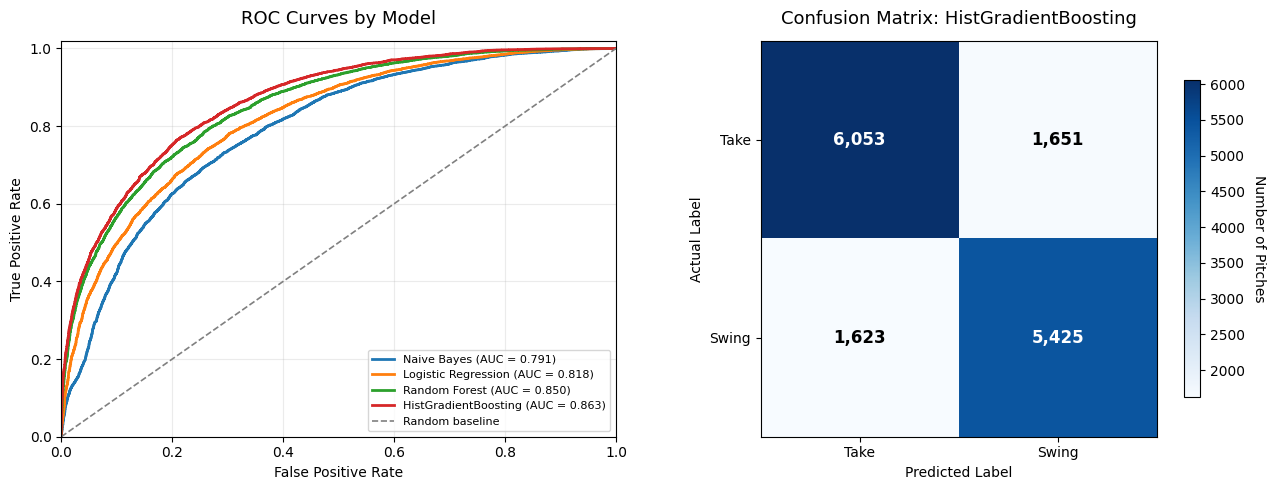

Classification report for HistGradientBoosting:

              precision    recall  f1-score   support

        Take       0.79      0.79      0.79      7704
       Swing       0.77      0.77      0.77      7048

    accuracy                           0.78     14752
   macro avg       0.78      0.78      0.78     14752
weighted avg       0.78      0.78      0.78     14752



In [79]:
# models to include in the ROC curve
roc_models = [
    "Naive Bayes",
    "Logistic Regression",
    "Random Forest",
    "HistGradientBoosting"
]

# create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# plot ROC curves
for model_name in roc_models:
    fpr, tpr, _ = roc_curve(y_test, model_scores[model_name])
    auc_value = results_df.loc[model_name, "roc_auc"]

    axes[0].plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_value:.3f})"
    )

# random baseline line
axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.2,
    label="Random baseline"
)

axes[0].set_title("ROC Curves by Model", fontsize=13, pad=12)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

# get best model by ROC-AUC
best_model_name = results_df["roc_auc"].idxmax()
best_model = fitted_models[best_model_name]

# predict using best model
best_pred = best_model.predict(X_test)

# create confusion matrix
cm = confusion_matrix(y_test, best_pred)

im = axes[1].imshow(cm, cmap="Blues")

axes[1].set_title(f"Confusion Matrix: {best_model_name}", fontsize=13, pad=12)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Take", "Swing"])

axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Take", "Swing"])

# add counts inside the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]

        axes[1].text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if value > cm.max() / 2 else "black"
        )

# add colorbar
cbar = fig.colorbar(im, ax=axes[1], shrink=0.8)
cbar.set_label("Number of Pitches", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# print classification report
print(f"Classification report for {best_model_name}:\n")

print(
    classification_report(
        y_test,
        best_pred,
        target_names=["Take", "Swing"]
    )
)

Overall, the ROC curves show that with boosted models, swings and takes are more clearly separated than with the other models, almost at every threshold. The HistGradientBoosting model has the best ROC-AUC value, standing at approximately **0.862**, indicating that this model is the best at ranking pitches with respect to the likelihood of swings.

As evidenced by the confusion matrix, the model also shows qualitative symmetry between the two outcomes. The model makes correct predictions of **6,014 takes** and **5,426 swings**, and of the two types of possible errors, the model also makes correct predictions of almost equal magnitude: **1,690 takes** are signaled as swings, and **1,622 swings** are signaled as takes. Thus, the model shows no systematic bias towards predicting one class as opposed to the other.

This balance is also demonstrated in the results of the classification report. For both events, the report cites approximately equal values of between **0.77-0.79** for precision, recall, and F1-score. The model shows adequate symmetry between the two outcome events, as the model aims to predict both events adequately, and not just the outcome that is predominant.



#### (5.3) Feature Importance Using Permutation

To see how our final model depends on specific predictors, we calculate permutation importance on the held-out test set. Permutation importance works by shuffling one feature at a time, leaving all other data as is. If a feature is important for the model, the accuracy would drop the most compared to other features.

Since the importance is based on test-set performance, it is not limited to the model's internal structure. Because of this, it is not as susceptible to the issues behind split-based importance in trees, where features with more split options or high-cardinality categories are valued more. To retain efficiency, we compute permutation importance on a random subsample of the test set, which is less important than giving a clear ranking with the strongest predictors.

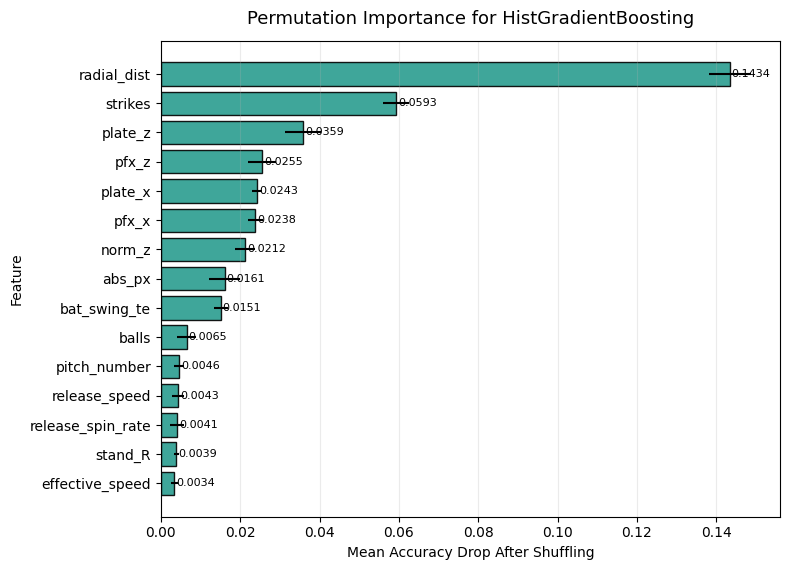

          feature  mean_accuracy_drop  std_accuracy_drop
      radial_dist              0.1434             0.0053
          strikes              0.0593             0.0033
          plate_z              0.0359             0.0046
            pfx_z              0.0255             0.0036
          plate_x              0.0243             0.0012
            pfx_x              0.0238             0.0019
           norm_z              0.0212             0.0025
           abs_px              0.0161             0.0040
     bat_swing_te              0.0151             0.0017
            balls              0.0065             0.0023
     pitch_number              0.0046             0.0013
    release_speed              0.0043             0.0015
release_spin_rate              0.0041             0.0018
          stand_R              0.0039             0.0007
  effective_speed              0.0034             0.0008


In [80]:
# choose a random test-set subsample for faster permutation importance
rng = np.random.RandomState(0)

sample_idx = rng.choice(
    len(X_test),
    size=min(6000, len(X_test)),
    replace=False
)

X_test_sample = X_test.iloc[sample_idx]
y_test_sample = y_test[sample_idx]

# compute permutation importance for the best model
perm_result = permutation_importance(
    best_model,
    X_test_sample,
    y_test_sample,
    n_repeats=6,
    random_state=0,
    scoring="accuracy",
    n_jobs=-1
)

# organize feature importance results
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_accuracy_drop": perm_result.importances_mean,
    "std_accuracy_drop": perm_result.importances_std
})

# keep the top 15 most important features
top_importance = (
    importance_df
    .sort_values("mean_accuracy_drop", ascending=False)
    .head(15)
    .sort_values("mean_accuracy_drop")
)

# plot top feature importances
fig, ax = plt.subplots(figsize=(8, 5.8))

ax.barh(
    top_importance["feature"],
    top_importance["mean_accuracy_drop"],
    xerr=top_importance["std_accuracy_drop"],
    color=PAL["accent"],
    edgecolor="black",
    alpha=0.9
)

ax.set_title(
    f"Permutation Importance for {best_model_name}",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Mean Accuracy Drop After Shuffling")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)

# add value labels
for i, value in enumerate(top_importance["mean_accuracy_drop"]):
    ax.text(
        value + 0.0005,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# print top features from most to least important
print(
    importance_df
    .sort_values("mean_accuracy_drop", ascending=False)
    .head(15)
    .round(4)
    .to_string(index=False)
)

The results of the permutation importance analysis indicate that the locations of the pitches and their counts are the most prominent factors the model relies on. The strongest of these predictors is `radial_dist`. When `radial_dist` is shuffled, the average accuracy drops around **0.143**. No other feature comes close to this drop, showing that this is the most important factor when determining if a batter will swing. The second strongest predictor is `strikes`. When `strikes` is shuffled, the average accuracy drops by around **0.060**. This shows that pitch count also plays a key role in determining if a batter will swing.

Beyond these two features, the most significant remaining features are also mostly determined by pitch location. These are `plate_z`, `plate_x`, `norm_z`, and `abs_px`. The features `pfx_z` and `pfx_x` also have limited movement, and while they are important, they play a much smaller role. The batter tendency feature, `bat_swing_te` provides useful personalization. The pitcher tendency feature is much weaker.

These results correspond with the previous EDA. Hitters primarily base their reaction on the location of the pitch and the count. Other factors such as pitch type, speed, and handedness, as well as player tendencies, provide some value, but are much less important when compared with location and count. Since permutation importance evaluates the importance of individual features in a vacuum, some of the features with lesser importance may still provide some value when combined with the more important features. This is the reason why the ablation study is helpful.

### 5.4 Ablation Study

An ablation study is used to assess contributions of feature groups. Here, we take out each feature group one at a time, retrain the given model, and compare the new test ROC-AUC with the ROC-AUC of the complete model.

Feature groups of which the model’s prediction performance deteriorates the most are the feature groups which are the most important for the prediction. If the performance decay is small, then the group is redundant to other groups which are already present. This way, we can assess the importance of feature groups rather than important feature groups.




Full model ROC-AUC: 0.8633

        removed_group  auc_without_group  delta_auc  auc_lost
             Location             0.6476    -0.2157    0.2157
Velocity and movement             0.8465    -0.0169    0.0169
                Count             0.8509    -0.0124    0.0124
              Matchup             0.8597    -0.0036    0.0036
      Player tendency             0.8628    -0.0005    0.0005
           Pitch type             0.8630    -0.0004    0.0004
             Sequence             0.8631    -0.0002    0.0002


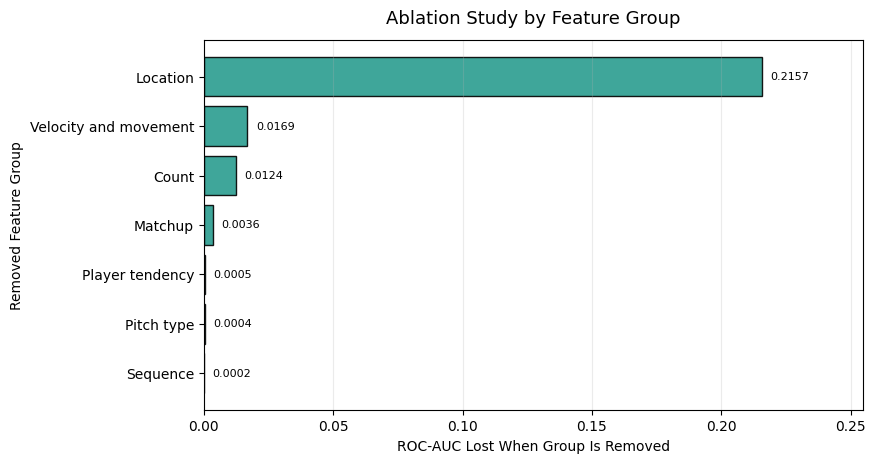

In [81]:
# define feature groups for ablation
feature_groups = {
    "Location": [
        "plate_x", "plate_z", "abs_px", "norm_x", "norm_z", "radial_dist", "in_zone"
    ],

    "Count": [
        "balls", "strikes", "two_strike", "three_ball",
        "count_diff", "hitter_count", "pitcher_count"
    ],

    "Pitch type": [
        col for col in X_train.columns if col.startswith("pitch_group")
    ],

    "Velocity and movement": [
        "release_speed", "effective_speed", "pfx_x", "pfx_z", "release_spin_rate"
    ],

    "Matchup": [
        "platoon", "stand_R", "throw_R"
    ],

    "Sequence": [
        "prev_swing", "prev_in_zone", "is_first_pitch", "pitch_number"
    ],

    "Player tendency": [
        "bat_swing_te", "pit_swing_te"
    ]
}

# function to fit HistGradientBoosting and return test ROC-AUC
def get_auc(feature_columns):
    model = HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.08,
        max_leaf_nodes=63,
        l2_regularization=1.0,
        random_state=42
    )

    model.fit(X_train[feature_columns], y_train)

    pred_prob = model.predict_proba(X_test[feature_columns])[:, 1]

    return roc_auc_score(y_test, pred_prob)

# full model AUC using all features
all_features = list(X_train.columns)
full_auc = get_auc(all_features)

# run ablation by removing one feature group at a time
ablation_results = []

for group_name, group_columns in feature_groups.items():
    # only remove columns that are actually in the design matrix
    group_columns = [
        col for col in group_columns
        if col in X_train.columns
    ]

    # keep all features except the selected group
    remaining_features = [
        col for col in X_train.columns
        if col not in group_columns
    ]

    # fit model without this feature group
    ablated_auc = get_auc(remaining_features)

    # negative delta means performance dropped after removing the group
    delta_auc = ablated_auc - full_auc

    ablation_results.append({
        "removed_group": group_name,
        "auc_without_group": ablated_auc,
        "delta_auc": delta_auc,
        "auc_lost": -delta_auc
    })

# organize ablation results
ablation_df = (
    pd.DataFrame(ablation_results)
    .sort_values("auc_lost", ascending=True)
)

# print results
print(f"Full model ROC-AUC: {full_auc:.4f}\n")

print(
    ablation_df
    .sort_values("auc_lost", ascending=False)
    .round(4)
    .to_string(index=False)
)

# plot AUC lost when each group is removed
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.barh(
    ablation_df["removed_group"],
    ablation_df["auc_lost"],
    color=PAL["accent"],
    edgecolor="black",
    alpha=0.9
)

ax.set_title("Ablation Study by Feature Group", fontsize=13, pad=12)
ax.set_xlabel("ROC-AUC Lost When Group Is Removed")
ax.set_ylabel("Removed Feature Group")
ax.grid(axis="x", alpha=0.25)

# add extra space on the right so labels do not get cut off
x_max = ablation_df["auc_lost"].max()
ax.set_xlim(0, x_max * 1.18)

# add value labels
for i, value in enumerate(ablation_df["auc_lost"]):
    ax.text(
        value + x_max * 0.015,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=8
    )

The ablation study proves location features are essential to the swing/take model. When the location features are absent, the ROC-AUC value decreases dramatically to **0.6476** from **0.8633**. No other group of features caused a significant deterioration to the model. Obviously, the location of a pitch is critical to the model.

The next most critical groups are velocity, movement, and count, in that order. Loss of velocity and movement features caused a drop in AUC of **0.017**. Removal of count features decreased AUC by **0.012**. Clearly, shape, speed, and pitch count are of some value to the model, but are not as critical as location.

The groups of features that are left provide an even smaller incremental value. Matchup, player tendencies, pitch type, and pitch sequence features provide only a minor tweak in AUC. Absence of these features does not mean they are of no value. They bring a more refined prediction, but only in cases of higher ambiguity, e.g. prediction of swings for pitches that are close to the edge of the strike zone.

The ablation study is ultimately decisive and clear on the value of the designed features. While they all bring some value, location is overwhelmingly the strongest signal, and velocity, movement, and count provide a secondary, and of less value, contribution.


### 5.5 Calibration

For this project, we care not only about whether the model predicts **swing** or **take** correctly, but also about the meaning of the predicted probabilities. As an example, consider the model that predicts a pitch to have a 70% probability of a swing. Pitches that the model predicts to have a 70% probability of a swing should be swung at 70% of the time.

We can assess this using a calibration curve (or reliability curve). This curve shows (for each probability) the model’s predicted probability of a swing and the actual probability of a swing in the test data. A model that is well-calibrated will fall close to the diagonal, meaning that the model’s predicted probabilities will reflect the actual probabilities of a swing.

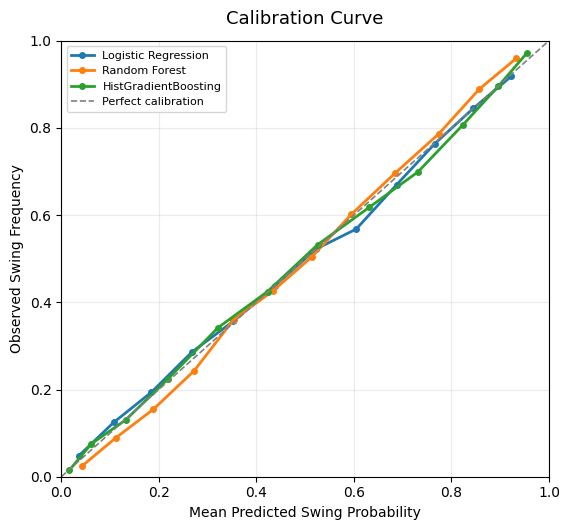

In [82]:
# models to compare in the calibration plot
calibration_models = [
    "Logistic Regression",
    "Random Forest",
    "HistGradientBoosting"
]

# create calibration plot
fig, ax = plt.subplots(figsize=(5.8, 5.4))

for model_name in calibration_models:
    if model_name in model_scores:
        observed_rate, predicted_prob = calibration_curve(
            y_test,
            model_scores[model_name],
            n_bins=12,
            strategy="quantile"
        )

        ax.plot(
            predicted_prob,
            observed_rate,
            marker="o",
            linewidth=2,
            markersize=4,
            label=model_name
        )

# perfect calibration reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.2,
    label="Perfect calibration"
)

ax.set_title("Calibration Curve", fontsize=13, pad=12)
ax.set_xlabel("Mean Predicted Swing Probability")
ax.set_ylabel("Observed Swing Frequency")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The calibration curve shows that the predicted probabilities are meaningful, and not only helpful for classification. Overall, the three models predicted the swing probabilities and matched the observed swing frequencies, as they are expected to fall on the diagonal reference line. For example, swing predictions that are assigned a 70% probability of being swung at are expected to be swung at 70% of the time.

HistGradientBoosting stays on the diagonal for a majority of the probability range. This is beneficial because the project uses the model output to estimate the probability of a swing, as opposed to simply predicting a swing/take decision. Due to the reasonable probability calibration, we can use the model outputs to construct swing-probability surfaces and to estimate the likelihood of a swing at different pitch locations and counts.

While the model output does show some deviations on the probability scale at the extremes, the probability outputs generally fall on the correct rate. The model is effective at estimating the likelihood of a swing at a pitch, and, in the process, outputs probabilities that are fairly accurate to actual swing rates.

### 5.6 Hyperparameter Sensitivity

To determine if the boosting model is stable, we examine how model performance changes with different values of two important hyperparameters, `learning_rate` and `max_leaf_nodes`.

The `learning_rate` hyperparameter adjusts how the model is updated with the addition of new trees. Decreasing the `learning_rate` gives the model more time to learn, which generally leads to more stable models. However, larger values of `learning_rate` can lead to faster learning at the expense of overfitting. The `max_leaf_nodes` hyperparameter builds trees of varying complexity. Trees with fewer `max_leaf_nodes` are simpler, while trees with more `max_leaf_nodes` can capture more complex interactions.

Because each of these hyperparameters builds models of different characteristics, we examine the held-out ROC-AUC from the same test split of the data, looking for model sensitivity to an exact hyperparameter value versus insensitivity to hyperparameter values within a range. This is a sensitivity test, not a distinct validation procedure.

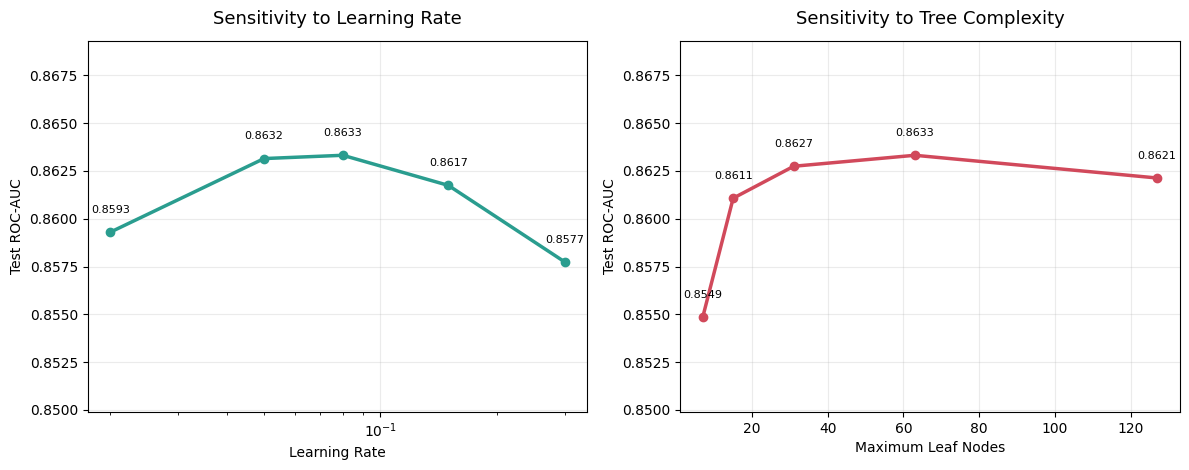

AUC by learning rate:
  learning_rate=0.02: AUC=0.8593
  learning_rate=0.05: AUC=0.8632
  learning_rate=0.08: AUC=0.8633
  learning_rate=0.15: AUC=0.8617
  learning_rate=0.3: AUC=0.8577

AUC by max_leaf_nodes:
  max_leaf_nodes=7: AUC=0.8549
  max_leaf_nodes=15: AUC=0.8611
  max_leaf_nodes=31: AUC=0.8627
  max_leaf_nodes=63: AUC=0.8633
  max_leaf_nodes=127: AUC=0.8621


In [83]:
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["mathtext.fontset"] = "dejavusans"
plt.rcParams["axes.unicode_minus"] = False

# values to test for learning rate and tree complexity
learning_rates = [0.02, 0.05, 0.08, 0.15, 0.30]
max_leaf_options = [7, 15, 31, 63, 127]

# store AUC results
auc_by_learning_rate = []
auc_by_max_leaves = []

# test different learning rates
for learning_rate in learning_rates:
    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=learning_rate,
        max_leaf_nodes=63,
        l2_regularization=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, pred_prob)

    auc_by_learning_rate.append(auc)

# test different tree complexities
for max_leaves in max_leaf_options:
    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.08,
        max_leaf_nodes=max_leaves,
        l2_regularization=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, pred_prob)

    auc_by_max_leaves.append(auc)

# create sensitivity plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# learning rate plot
axes[0].plot(
    learning_rates,
    auc_by_learning_rate,
    marker="o",
    linewidth=2.5,
    color=PAL["accent"]
)

axes[0].set_xscale("log")
axes[0].set_title("Sensitivity to Learning Rate", fontsize=13, pad=12)
axes[0].set_xlabel("Learning Rate")
axes[0].set_ylabel("Test ROC-AUC")
axes[0].grid(alpha=0.25)

# add value labels
for x, y in zip(learning_rates, auc_by_learning_rate):
    axes[0].text(
        x,
        y + 0.001,
        f"{y:.4f}",
        ha="center",
        fontsize=8
    )

# tree complexity plot
axes[1].plot(
    max_leaf_options,
    auc_by_max_leaves,
    marker="o",
    linewidth=2.5,
    color=PAL["swing"]
)

axes[1].set_title("Sensitivity to Tree Complexity", fontsize=13, pad=12)
axes[1].set_xlabel("Maximum Leaf Nodes")
axes[1].set_ylabel("Test ROC-AUC")
axes[1].grid(alpha=0.25)

# add value labels
for x, y in zip(max_leaf_options, auc_by_max_leaves):
    axes[1].text(
        x,
        y + 0.001,
        f"{y:.4f}",
        ha="center",
        fontsize=8
    )

# make y-axis limits tight enough to show differences clearly
all_auc_values = auc_by_learning_rate + auc_by_max_leaves
y_min = min(all_auc_values) - 0.005
y_max = max(all_auc_values) + 0.006

axes[0].set_ylim(y_min, y_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

# print numeric results
print("AUC by learning rate:")
for learning_rate, auc in zip(learning_rates, auc_by_learning_rate):
    print(f"  learning_rate={learning_rate}: AUC={auc:.4f}")

print("\nAUC by max_leaf_nodes:")
for max_leaves, auc in zip(max_leaf_options, auc_by_max_leaves):
    print(f"  max_leaf_nodes={max_leaves}: AUC={auc:.4f}")

The results of the sensitivity analysis demonstrate that the boosting model remains robust throughout the analysis. With all combinations of the learning rates and tree sizes, the ROC-AUC was consistently about **0.86**, indicating that the model was not relying on any specific combination for optimal performance.

When the learning rate was set to **0.08**, the model performed the best, but was also accepted in the range of ***0.05 to 0.08**. A learning rate of **0.02** resulted in a learning rate that was too slow and inefficient, while a learning rate of **0.30** resulted in a learning rate that was set too large, resulting in performance decline due to insufficient updates of the model with each added tree.

The effect of tree complexity was also examined. It was found that performance increased as `max_leaf_nodes` increased from **7** to **63**, with only minor decreases observed at **127**. From this, it can be concluded that models with a small number of leaves (63) are likely to be too simple (and possibly underfitting), while models with a large number of leaves are too complex (and likely overfitting).

The hyperparameters `learning_rate=0.08` and `max_leaf_nodes=63` were not set randomly, as the ranges of these parameters exhibited robustness.

#### (5.7) Case Study: Where the Model Performs Well and Where It Fails

To gain additional insight into the model’s behavior, we analyze specific case examples alongside standard evaluation metrics. In this analysis, we pay particular attention to the model’s most confident correct and incorrect predictions.

Predictions that the model makes with confidence and are also correct typically indicate clear cut examples to the model, like clear swing or take predictions which might be examples of pitches that are either in the middle of the strike zone or far out of the strike zone. We gain even more from studying the most confident incorrect predictions, as we are able to gain insight into the most ambiguous cases the model deals with, like a borderline case that has a pitch location, count, or even a hitter that has a specific tendency which leads to differing predictions with varying conclusions.

This case study also serves our understanding and interpretation of the model and its predictions in a baseball context. Because of this, we are able to say with confidence that the model performs best with the most obvious examples of pitch predictions and struggles the most with the nuanced examples that might even contain disagreements from human experts.


Most confident correct swing predictions:
 radial_dist  in_zone  balls  strikes pitch_group  p_swing  predicted_swing  swing
       0.752        1      1        2    Fastball    0.987                1      1
       0.351        1      1        2    Fastball    0.986                1      1
       0.880        1      2        2    Fastball    0.986                1      1
       0.777        1      3        2    Fastball    0.985                1      1
       0.532        1      1        2    Fastball    0.985                1      1

Most confident wrong predictions:
 radial_dist  in_zone  balls  strikes pitch_group  p_swing  predicted_swing  swing  confidence
       3.854        0      2        2    Breaking    0.001                0      1       0.499
       2.520        0      0        2    Fastball    0.008                0      1       0.492
       3.602        0      0        2    Breaking    0.009                0      1       0.491
       2.745        0      1        2    Fast

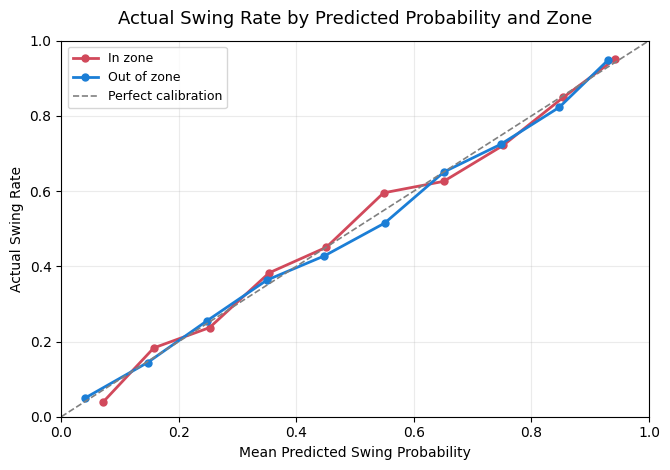

In [84]:
# get predicted swing probabilities from the best model
predicted_swing_prob = best_model.predict_proba(X_test)[:, 1]

# make a case-study dataframe from the test set
case_df = test.copy()

# add model prediction information
case_df["p_swing"] = predicted_swing_prob
case_df["predicted_swing"] = (case_df["p_swing"] >= 0.50).astype(int)
case_df["correct"] = case_df["predicted_swing"] == case_df["swing"]
case_df["confidence"] = (case_df["p_swing"] - 0.50).abs()

# columns to show in the case-study tables
case_cols = [
    "radial_dist",
    "in_zone",
    "balls",
    "strikes",
    "pitch_group",
    "p_swing",
    "predicted_swing",
    "swing"
]

# most confident correct swing predictions
correct_swings = (
    case_df[(case_df["correct"]) & (case_df["swing"] == 1)]
    .sort_values("p_swing", ascending=False)
    [case_cols]
    .head(5)
    .round(3)
)

print("Most confident correct swing predictions:")
print(correct_swings.to_string(index=False))

# most confident wrong predictions
wrong_cases = (
    case_df[~case_df["correct"]]
    .sort_values("confidence", ascending=False)
    [case_cols + ["confidence"]]
    .head(8)
    .round(3)
)

print("\nMost confident wrong predictions:")
print(wrong_cases.to_string(index=False))

# create bins of predicted swing probability
case_df["prob_bin"] = pd.cut(
    case_df["p_swing"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

# summarize actual swing rate by predicted probability bin and zone status
profile = (
    case_df
    .groupby(["in_zone", "prob_bin"], observed=True)
    .agg(
        mean_predicted_prob=("p_swing", "mean"),
        actual_swing_rate=("swing", "mean"),
        n=("swing", "size")
    )
    .reset_index()
)

# create reliability plot split by zone status
fig, ax = plt.subplots(figsize=(6.8, 4.8))

zone_labels = {
    1: "In zone",
    0: "Out of zone"
}

zone_colors = {
    1: PAL["swing"],
    0: PAL["take"]
}

for zone_value in [1, 0]:
    zone_profile = profile[profile["in_zone"] == zone_value]

    ax.plot(
        zone_profile["mean_predicted_prob"],
        zone_profile["actual_swing_rate"],
        marker="o",
        linewidth=2,
        markersize=5,
        color=zone_colors[zone_value],
        label=zone_labels[zone_value]
    )

# perfect calibration reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.2,
    label="Perfect calibration"
)

ax.set_title("Actual Swing Rate by Predicted Probability and Zone", fontsize=13, pad=12)
ax.set_xlabel("Mean Predicted Swing Probability")
ax.set_ylabel("Actual Swing Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Where does the model performs well?**

- The model is most confident in making accurate predictions around clear swing/take decisions. An example is the predicted swing probability given a two-strike count. Given two strikes, a swing is almost certain, and if the pitch is near the zone, predicted probability is around 1.00. The model is also consistent, providing low predicted probability of swings for pitches that are far from the hit zone that are taken.

**Where does the model struggle?**

- Many of the confident incorrect predictions that show other limitations of the model include the swings on pitches that are far from the zone that are predicted to be taken. These are not random, and will include swings that are far from the zone due to the hitter’s mechanism (which could have caused the pitch to look more hittable than it is), pitch deception, etc. The decisions to swing often have more information (potentially catchable) than the count, the location of the pitch, etc.

The model is also well calibrated as seen in the reliability plot. Predicted probabilities of swings mostly correspond to the observed rates, and are typically close to the diagonal. The segments that show the most uncertainty are the predicted probabilities around the center (which correspond to the most divided decisions), and show the most uncertainty.
